# Use Case: Customer Churn Prediction for a Telecom Company

# Project Overview

A telecommunications operator aims to reduce customer churn. To achieve this, the company plans to offer promotional codes and special conditions to customers who are likely to cancel their service. In order to identify such users in advance, the company needs a model that can predict whether a customer will cancel their contract. The operator’s team has collected personal information about some customers, as well as data about their service plans and the services they use. The goal of this project is to train and compare several machine learning models and select the best one for predicting customer churn.

# Service Description

The operator provides two main types of services:

- `Landline telephone service.` A phone can be connected to multiple lines simultaneously.
- `Internet service.` Two types of connection are available: via a telephone line using `DSL (Digital Subscriber Line)` or via `fiber-optic cable`.

Customers also have access to several additional services:

- `Internet security:` antivirus protection (*Device Protection*) and blocking of unsafe websites (*Online Security*);
- `Dedicated technical support line` (*Tech Support*);
- `Cloud storage for data backup` (*Online Backup*);
- `Streaming television` (*Streaming TV*) and a `movie catalog` (*Streaming Movies*).

Customers can pay for services monthly or once every 1-2 years. Various payment methods are available, including the option to receive an electronic billing statement.

# Data Description

The data is stored in an SQLite database, which is contained in a single file. The database includes several tables:
- `contract` - information about customer contracts
- `personal` - customers' personal data
- `internet` - information about internet services
- `phone` - information about phone services

**Table `contract`:**
- `customerID` - subscriber ID
- `BeginDate` - contract start date
- `EndDate` - contract end date
- `Type` - payment type: monthly or once every 1-2 years
- `PaperlessBilling` - electronic billing statement
- `PaymentMethod` - payment method
- `MonthlyCharges` - monthly charges
- `TotalCharges` - total charges paid by the subscriber

**Table `personal`:**
- `customerID` - customer ID
- `gender` - gender
- `SeniorCitizen` - whether the subscriber is a senior citizen
- `Partner` - whether the subscriber has a partner/spouse
- `Dependents` - whether the subscriber has children

**Table `internet`:**
- `customerID` - customer ID
- `InternetService` - type of internet connection
- `OnlineSecurity` - protection from unsafe websites
- `OnlineBackup` - cloud storage for data backup
- `DeviceProtection` - antivirus protection
- `TechSupport` - dedicated technical support line
- `StreamingTV` - streaming television service
- `StreamingMovies` - movie streaming catalog

**Table `phone`:**
- `customerID` - customer ID
- `MultipleLines` - whether the phone service supports multiple lines simultaneously

The contract information in the dataset is valid as of `February 1, 2020`.

# Table of Contents

1. [Data Loading and Overview](#Data-Loading-and-Overview)
2. [EDA, Data Preprocessing, and Preparation for Model Training](#EDA,-Data-Preprocessing,-and-Preparation-for-Model-Training)  
   2.1 [Analysis and Preprocessing of Each Table](#Analysis-and-Preprocessing-of-Each-Table)  
   2.2 [Creating a Unified DataFrame](#Creating-a-Unified-DataFrame)  
   2.3 [Analysis and Preprocessing of the Unified Dataset](#Analysis-and-Preprocessing-of-the-Unified-Dataset)  
   2.3.1 [Target Variable Creation](#Target-Variable-Creation)  
   2.3.2 [Feature Engineering](#Feature-Engineering)  
   2.3.3 [EDA of Categorical Features](#EDA-of-Categorical-Features)  
   2.3.4 [EDA of Numerical Features](#EDA-of-Numerical-Features)  
   2.3.5 [Correlation Analysis](#Correlation-Analysis)  
   2.4 [Data Preparation for Model Training](#Data-Preparation-for-Model-Training)
3. [Model Training](#Model-Training)  
   3.1 [Model Selection](#Model-Selection)  
   3.2 [Baseline Model Training](#Baseline-Model-Training)  
   3.3 [Hyperparameter Tuning for the Best Model](#Hyperparameter-Tuning-for-the-Best-Model)
4. [Testing the Best Model](#Testing-the-Best-Model)  
   4.1 [Best Model Performance on the Test Set](#Best-Model-Performance-on-the-Test-Set)  
   4.2 [Confusion Matrix of the Best Model](#Confusion-Matrix-of-the-Best-Model)  
   4.3 [Precision and Recall Analysis of the Best Model](#Precision-and-Recall-Analysis-of-the-Best-Model)  
   4.4 [Optimal Threshold Selection](#Optimal-Threshold-Selection)  
   4.5 [Feature Importance Analysis](#Feature-Importance-Analysis)  
   4.6 [Analysis of Customer Tenure](#Analysis-of-Customer-Tenure)
5. [Conclusion](#Conclusion)

## Data Loading and Overview

First, let's import all necessary packages and libraries.

In [1]:
# install the library for calculating the phik correlation
!pip install -q phik

In [2]:
# disable warnings to keep the output clean
import warnings
warnings.filterwarnings("ignore")

# import libraries for data manipulation and numerical computations
import pandas as pd
import numpy as np

# set random state for reproducibility
RANDOM_STATE = 20326

# configure display of floating numbers with two decimal places
pd.set_option('display.float_format', '{:.2f}'.format)

# import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# import phik library for calculating and visualizing the correlation matrix
from phik import phik_matrix
from phik.report import plot_correlation_matrix

# import module for working with file system paths
from pathlib import Path

# import module for creating a database connection
from sqlalchemy import create_engine

# import sklearn tools for data preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# import distributions for RandomizedSearchCV
from scipy.stats import randint, loguniform

# import classification models
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier

# import metrics for model evaluation
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

Now, let's load the data. To do this, we will specify the path to the database file `ds-plus-final.db` and establish a connection to SQLite.

In [3]:
# specify the path to the 'ds-plus-final.db' file
db_path = Path('ds-plus-final.db')

In [4]:
# check if the database file exists
if not db_path.exists():
    raise FileNotFoundError(f'Database file not found: {db_path}')

In [5]:
# create a connection to the SQLite database
engine = create_engine(f'sqlite:///{db_path}', echo=False)

The connection to the database has been successfully established. Next, we will examine the tables contained in the database.

In [6]:
# create an SQL query to retrieve the list of tables
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

In [7]:
# execute the query and store the result in a dataframe
tables = pd.read_sql(query, engine)

In [8]:
# display the list of tables
tables

,name
0,data_arc
1,data_bulk
2,data_bulk_time
3,data_wire_time
4,contract
5,personal
6,phone
7,internet
8,data_gas
9,data_temp


The database contains 11 tables. For the customer churn prediction task, we will use only four tables: `contract`, `personal`, `internet`, and `phone`. Each of these tables will be loaded and stored in a separate dataframe.

In [9]:
# create a list of tables
tables_telecom = ['contract', 'personal', 'internet', 'phone']

In [10]:
# create an empty dictionary to store dataframes
dfs = {}

In [11]:
# load each table from the database into a dictionary
for table in tables_telecom:
    dfs[table] = pd.read_sql(f"SELECT * FROM {table}", engine)

In [12]:
# store the tables in separate dataframes
contract = dfs['contract']
personal = dfs['personal']
internet = dfs['internet']
phone = dfs['phone']

In [13]:
# check the result
for name, df in dfs.items():
    print(f'{"-"*120}')
    print(f'First rows of the table: {name}')
    print(f'{"-"*120}')
    display(df.head(2))

------------------------------------------------------------------------------------------------------------------------
First rows of the table: contract
------------------------------------------------------------------------------------------------------------------------


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84


------------------------------------------------------------------------------------------------------------------------
First rows of the table: personal
------------------------------------------------------------------------------------------------------------------------


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No


------------------------------------------------------------------------------------------------------------------------
First rows of the table: internet
------------------------------------------------------------------------------------------------------------------------


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No


------------------------------------------------------------------------------------------------------------------------
First rows of the table: phone
------------------------------------------------------------------------------------------------------------------------


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No


The data has been successfully loaded. We will now proceed with data exploration, preprocessing, and preparation for model training.

**Summary**

<div style="border:solid lightblue 3px; padding: 20px">

In this chapter, the following steps were performed:

- A connection to the SQLite database was established, and the data were successfully loaded from the file `ds-plus-final.db`.
- The database contains 11 tables, but for the customer churn prediction task only 4 tables (`contract`, `personal`, `internet`, `phone`) were selected, as they contain information about contracts, customers, and services.
- Each table was loaded and stored in a separate dataframe.
- It was verified that the data were loaded without errors and are available for further analysis and joining the tables.

Next, exploratory data analysis (EDA) will be conducted, followed by data preprocessing and preparation for model training.

## EDA, Data Preprocessing, and Preparation for Model Training

### Analysis and Preprocessing of Each Table

First, let's explore the general information for each table. To do this, we will create a custom function called `explo_data`.

In [14]:
# create the custom function
def explo_data(df: pd.DataFrame, n: int = 5):
    """
    Quick overview of a dataframe: head, shape, columns, types, missing values, duplicates, statistics.
    
    Parameters:
        - df (pd.DataFrame): dataframe to analyze
        - n (int): number of rows to display (default=5)
    
    Example:
    explo_data(train_df, n=10)
    """

    print("-"*110)
    print("First rows:")
    display(df.head(n))

    print("-"*110)
    print("DataFrame shape:")
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

    print("-"*110)
    print("Column names:")
    print(list(df.columns))

    print("-"*110)
    print("DataFrame info:")
    df.info()

    print("-"*110)
    print("Missing values (count and %, sorted descending):")
    missing_data = (
        df.isna().sum()
        .to_frame(name='count')
        .assign(percent=lambda x: (x['count'] / len(df) * 100).round(2))
        .sort_values(by='count', ascending=False)
    )
    display(missing_data)

    print("-"*110)
    print("Rows with missing values (first n rows):")
    display(df[df.isna().any(axis=1)].head(n))

    print("-"*110)
    print("Duplicate rows:")
    print(f"Number of duplicates: {df.duplicated().sum()}")

    print("-"*110)
    print("Duplicate rows (first n rows):")
    display(df[df.duplicated()].head(n))

    print("-"*110)
    print("Descriptive statistics:")
    display(df.describe())
    print("-"*110)

Let’s display general information for each table using the previously created `explo_data` function.

In [15]:
# apply the function to all tables from the dfs dictionary
for name, df in dfs.items():
    print(f'{"-"*60}')
    print(f'Analyzing table: {name}')
    print(f'{"-"*60}')
    explo_data(df)

------------------------------------------------------------
Analyzing table: contract
------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------
First rows:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


--------------------------------------------------------------------------------------------------------------
DataFrame shape:
Rows: 7043 | Columns: 8
--------------------------------------------------------------------------------------------------------------
Column names:
['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
--------------------------------------------------------------------------------------------------------------
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   BeginDate         7043 non-null   object
 2   EndDate           7043 non-null   object
 3   Type              7043 non-null   object
 4   PaperlessBilling  7043 non-null   object
 5   PaymentMethod     7043 non-null   object
 6  

,count,percent
customerID,0,0.00
BeginDate,0,0.00
EndDate,0,0.00
Type,0,0.00
PaperlessBilling,0,0.00
PaymentMethod,0,0.00
MonthlyCharges,0,0.00
TotalCharges,0,0.00


--------------------------------------------------------------------------------------------------------------
Rows with missing values (first n rows):


...

--------------------------------------------------------------------------------------------------------------
Duplicate rows:
Number of duplicates: 0
--------------------------------------------------------------------------------------------------------------
Duplicate rows (first n rows):


,CustomerId,MultipleLines


--------------------------------------------------------------------------------------------------------------
Descriptive statistics:


,CustomerId,MultipleLines
count,6361,6361
unique,6361,2
top,5575-GNVDE,No
freq,1,3390


--------------------------------------------------------------------------------------------------------------


So, the initial data overview revealed the following:

**Checking the overall structure of the tables:**
- The number and names of the tables match the task requirements.
- All tables contain data.

**Analysis of the `contract` table:**
- DataFrame shape: 7043 rows, 8 columns.
- No missing values or explicit duplicates were found.
- Column names should be converted to snake_case.
- Data types need to be corrected (dates and numerical features are currently stored as `object`).
- The meaning of `No` in the `EndDate` column needs to be clarified.

**Analysis of the `personal` table:**
- DataFrame shape: 7043 rows, 5 columns.
- No missing values or explicit duplicates were found.
- Column names should be converted to snake_case.
- Data types need to be checked and corrected.

**Analysis of the `internet` table:**
- DataFrame shape: 5517 rows, 8 columns.
- No missing values or explicit duplicates were found.
- Column names should be converted to snake_case.
- Data types need to be checked and corrected.

**Analysis of the `phone` table:**
- DataFrame shape: 6361 rows, 2 columns.
- No missing values or explicit duplicates were found.
- Column names should be converted to snake_case.
- Data types need to be checked and corrected.

**Key Points:**
- The number and names of the tables used are consistent with the task requirements.
- All tables contain data.
- Each table includes a user identifier column that can be used for joining. However, it is important to note that the number of rows in the `internet` and `phone` tables (5517 and 6361 respectively) is significantly lower than in the `contract` and `personal` tables (7043 each). This indicates that not all customers use internet and/or telephone services. This should be taken into account during joining, and a left join based on the main contract table will likely be appropriate.
- Before joining the tables, it is necessary to standardize column names and correct data types, as well as further investigate the `No` values in the `EndDate` column of the `contract` table.
- Additionally, before joining, a more detailed analysis of each table will be performed to identify potential anomalies and handle them if necessary.

For convenience in further work with the columns, we will convert their names to snake_case.

In [16]:
# create a function to convert column names to snake_case
def to_snake_case(columns):
    """Convert column names to snake_case format."""
    return (
        columns
        .str.replace('([a-z0-9])([A-Z])', r'\1_\2', regex=True)
        .str.replace(' ', '_')
        .str.replace('[^a-zA-Z0-9_]', '', regex=True)
        .str.lower()
    )

In [17]:
# apply the transformation to all tables
for name in dfs:
    dfs[name].columns = to_snake_case(dfs[name].columns)

In [18]:
# update each dataframe
contract = dfs['contract']
personal = dfs['personal']
internet = dfs['internet']
phone = dfs['phone']

In [19]:
# check the result
for name, df in dfs.items():
    print(f'{"-"*60}')
    print(f'Column names in table: {name}')
    print(f'{"-"*60}')
    print(df.columns.tolist())

------------------------------------------------------------
Column names in table: contract
------------------------------------------------------------
['customer_id', 'begin_date', 'end_date', 'type', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges']
------------------------------------------------------------
Column names in table: personal
------------------------------------------------------------
['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents']
------------------------------------------------------------
Column names in table: internet
------------------------------------------------------------
['customer_id', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']
------------------------------------------------------------
Column names in table: phone
------------------------------------------------------------
['customer_id', 'multiple_lines']


Now, let’s examine the `end_date` column from the `contract` table separately.

In [20]:
# check unique values in the 'end_date' column
contract['end_date'].value_counts().head(10)

end_date
No            5942
2020-01-01      39
2019-12-01      38
2018-11-01      35
2019-09-01      32
2019-10-01      31
2019-11-01      30
2019-03-01      28
2019-06-01      28
2018-09-01      28
Name: count, dtype: int64

For most customers, the value is `No` (5942 records), while the remaining customers have specific dates indicated. This means that `No` corresponds to an active customer as of the data reference date (`February 1, 2020`), whereas a specific date indicates that the customer has left.

In [21]:
# check the unique values of the 'begin_date' column
contract['begin_date'].value_counts().head(10)

begin_date
2014-02-01    366
2019-10-01    237
2019-11-01    237
2019-09-01    237
2020-01-01    233
2019-12-01    220
2014-03-01    178
2019-07-01    156
2019-08-01    146
2019-06-01    141
Name: count, dtype: int64

This table contains only date values. Next, we will convert the `begin_date` and `end_date` columns to the `datetime` type.

In [22]:
# convert 'begin_date' and 'end_date' to 'datetime' format
contract['begin_date'] = pd.to_datetime(contract['begin_date'])
contract['end_date'] = pd.to_datetime(contract['end_date'], errors='coerce')

In [23]:
# check the result
contract[['begin_date', 'end_date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   begin_date  7043 non-null   datetime64[ns]
 1   end_date    1101 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 110.2 KB


The columns `begin_date` and `end_date` were successfully converted to the `datetime` type. The values `No` in `end_date` were transformed into `NaT`, which allows us to preserve information about active customers and correctly use the reference date February 1, 2020 (the data snapshot date) when calculating contract duration after joining the tables.

Now, let’s take a closer look at the minimum and maximum dates in both columns.

In [24]:
# check the range of dates in 'begin_date'
print("Minimum contract start date:", contract['begin_date'].min())
print("Maximum contract start date:", contract['begin_date'].max())

Minimum contract start date: 2013-10-01 00:00:00
Maximum contract start date: 2020-02-01 00:00:00


In [25]:
# check the date range in 'end_date' excluding NaT
print("Minimum contract end date:", contract['end_date'].min())
print("Maximum contract end date:", contract['end_date'].max())

Minimum contract end date: 2014-06-01 00:00:00
Maximum contract end date: 2020-01-01 00:00:00


The date ranges appear to be valid. Contract start dates fall within the period from `October 1, 2013 to February 1, 2020`, which is consistent with the data reference date. Contract termination dates fall within the period from `June 1, 2014 to January 1, 2020`, which is logical and remains within the analyzed timeframe.

Now let’s move on to the `monthly_charges` and `total_charges` columns. We will check whether there are any hidden empty values in these columns. In some datasets, there may be no NaN values, but empty strings (`''`) or strings consisting only of whitespace can still be present.

In [26]:
# check for empty strings in 'monthly_charges' and 'total_charges'
print("Empty values in monthly_charges:", (contract['monthly_charges'].str.strip() == '').sum())
print("Empty values in total_charges:", (contract['total_charges'].str.strip() == '').sum())

Empty values in monthly_charges: 0
Empty values in total_charges: 11


There are 11 such values in the `total_charges` column. Let’s examine these rows in more detail.

In [27]:
# display rows with empty string values in 'total_charges'
contract.loc[contract['total_charges'].str.strip() == '']

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.0,
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.7,
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,


Missing values in `total_charges` are observed for customers whose contracts started on `February 1, 2020`, which corresponds to the data snapshot date. This indicates that these customers have just joined and have not yet accumulated any total charges, so the absence of values in this case is not a data error. Therefore, the missing values can be replaced with `0`.

In [28]:
# replace empty strings and whitespace-only values in 'total_charges' with NaN
contract['total_charges'] = contract['total_charges'].astype(str).str.strip()
contract.loc[contract['total_charges'] == '', 'total_charges'] = np.nan

In [29]:
# convert 'monthly_charges' and 'total_charges' to float type
contract['monthly_charges'] = pd.to_numeric(contract['monthly_charges'])
contract['total_charges'] = pd.to_numeric(contract['total_charges'], errors='coerce')

In [30]:
# replace missing values in 'total_charges' with 0
contract['total_charges'] = contract['total_charges'].fillna(0)
print("Number of missing values in total_charges after replacement:", contract['total_charges'].isna().sum())

Number of missing values in total_charges after replacement: 0


In [31]:
# check the result
contract[['monthly_charges', 'total_charges']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   monthly_charges  7043 non-null   float64
 1   total_charges    7043 non-null   float64
dtypes: float64(2)
memory usage: 110.2 KB


The columns `monthly_charges` and `total_charges` were successfully converted to the numeric `float` data type.

Now let's move on to analyzing the `senior_citizen` column in the `personal` table. First, we will verify that it contains only the values 0 and 1.

In [32]:
# check unique values in the 'senior_citizen' column
personal['senior_citizen'].value_counts()

senior_citizen
0    5901
1    1142
Name: count, dtype: int64

In [33]:
# check the data type
print("Data type before transformation:", personal['senior_citizen'].dtype)

Data type before transformation: object


In [34]:
# check which values are present in the column
print("Unique values:", personal['senior_citizen'].unique())

Unique values: ['0' '1']


The column contains only values 0 and 1, which confirms its binary nature. To ensure consistency in the representation of binary features across the project, the `senior_citizen` variable will be converted into a categorical format (`Yes = 1 / No = 0`), so that all binary features share the same representation.

In [35]:
# convert to string and map 0 to 'No' and 1 to 'Yes'
personal['senior_citizen'] = (
    personal['senior_citizen']
    .astype(str)
    .str.strip()
    .map({'0': 'No', '1': 'Yes'})
)

In [36]:
# check the result after transformation
print("After transformation:")
print(personal['senior_citizen'].value_counts())
print("Data type after transformation:", personal['senior_citizen'].dtype)
print("Number of missing values:", personal['senior_citizen'].isna().sum())

After transformation:
senior_citizen
No     5901
Yes    1142
Name: count, dtype: int64
Data type after transformation: object
Number of missing values: 0


All binary features in the dataset are now represented in a consistent format, which simplifies further analysis, preprocessing, and feature encoding for modeling. Next, we will move on to a more detailed analysis of the features in each table.

First, we will create a list of categorical columns for each table.

In [37]:
# create a function to analyze categorical features
def analyze_categorical(df, table_name):
    """
    Analyzes categorical features in a dataframe:
    - displays the number of unique values,
    - shows value counts,
    - for features with a small number of categories (<= 5), plots a pie chart.
    """
    print(f"{'-'*120}")
    print(f"Categorical features in table: {table_name}")
    print(f"{'-'*120}")
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        print(f"\nFeature: {col}")
        unique_vals = df[col].nunique()
        print(f"Number of unique values: {unique_vals}")
        value_counts = df[col].value_counts()
        display(value_counts)
        
        # visualize if the number of categories is small
        if unique_vals <= 5:
            plt.figure(figsize=(4, 4))
            value_counts.plot.pie(autopct='%1.1f%%')
            plt.title(f'Distribution: {col}')
            plt.ylabel('')
            plt.show()

------------------------------------------------------------------------------------------------------------------------
Categorical features in table: contract
------------------------------------------------------------------------------------------------------------------------

Feature: customer_id
Number of unique values: 7043


customer_id
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64


Feature: type
Number of unique values: 3


type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

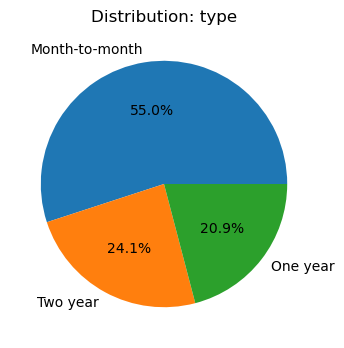


Feature: paperless_billing
Number of unique values: 2


paperless_billing
Yes    4171
No     2872
Name: count, dtype: int64

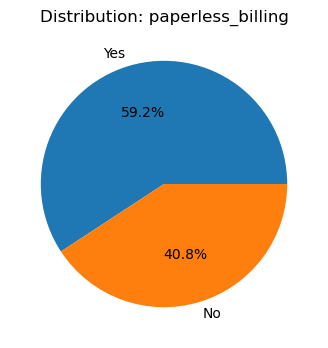


Feature: payment_method
Number of unique values: 4


payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

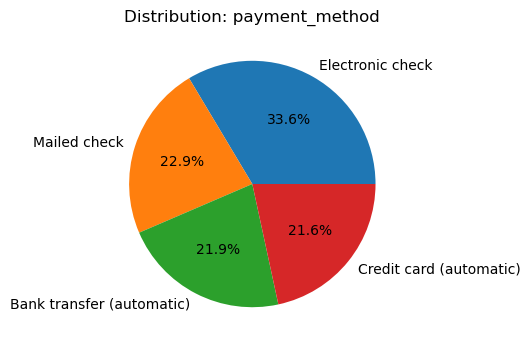

------------------------------------------------------------------------------------------------------------------------
Categorical features in table: personal
------------------------------------------------------------------------------------------------------------------------

Feature: customer_id
Number of unique values: 7043


customer_id
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64


Feature: gender
Number of unique values: 2


gender
Male      3555
Female    3488
Name: count, dtype: int64

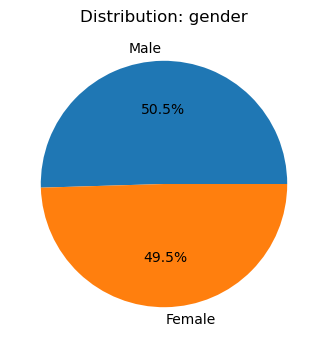


Feature: senior_citizen
Number of unique values: 2


senior_citizen
No     5901
Yes    1142
Name: count, dtype: int64

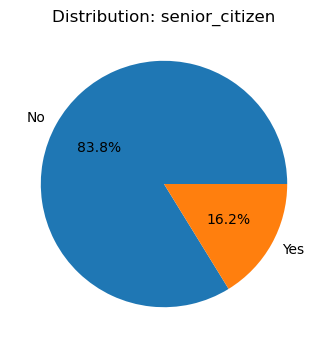


Feature: partner
Number of unique values: 2


partner
No     3641
Yes    3402
Name: count, dtype: int64

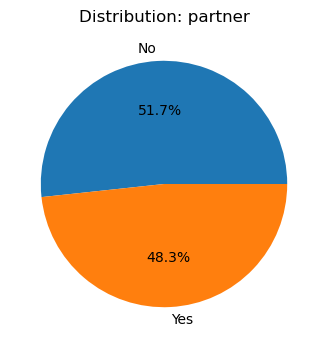


Feature: dependents
Number of unique values: 2


dependents
No     4933
Yes    2110
Name: count, dtype: int64

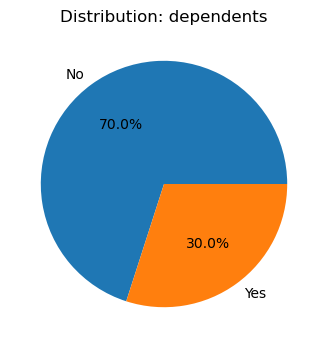

------------------------------------------------------------------------------------------------------------------------
Categorical features in table: internet
------------------------------------------------------------------------------------------------------------------------

Feature: customer_id
Number of unique values: 5517


customer_id
7590-VHVEG    1
5181-OABFK    1
9356-AXGMP    1
5176-OLSKT    1
7508-DQAKK    1
             ..
1104-FEJAM    1
2972-YDYUW    1
4238-JSSWH    1
0869-PAPRP    1
3186-AJIEK    1
Name: count, Length: 5517, dtype: int64


Feature: internet_service
Number of unique values: 2


internet_service
Fiber optic    3096
DSL            2421
Name: count, dtype: int64

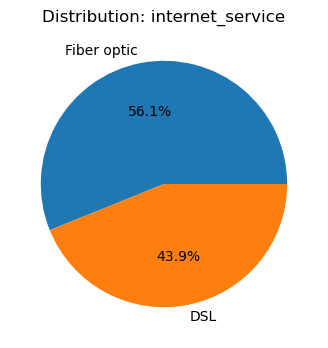


Feature: online_security
Number of unique values: 2


online_security
No     3498
Yes    2019
Name: count, dtype: int64

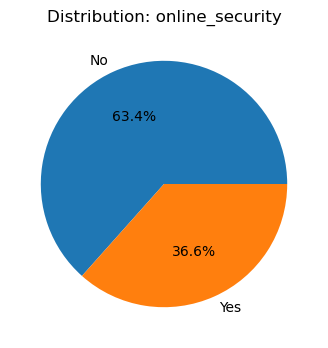


Feature: online_backup
Number of unique values: 2


online_backup
No     3088
Yes    2429
Name: count, dtype: int64

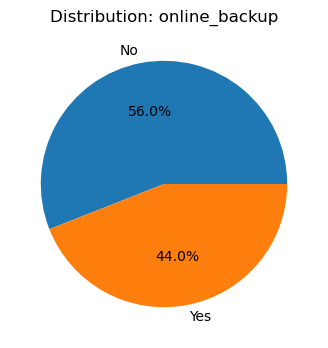


Feature: device_protection
Number of unique values: 2


device_protection
No     3095
Yes    2422
Name: count, dtype: int64

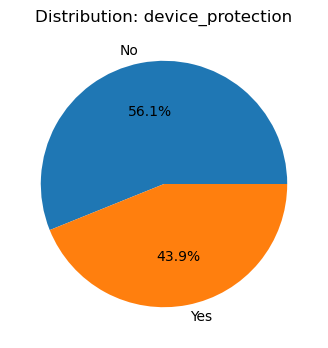


Feature: tech_support
Number of unique values: 2


tech_support
No     3473
Yes    2044
Name: count, dtype: int64

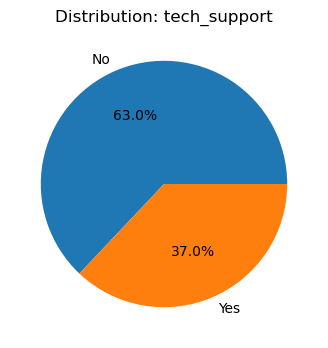


Feature: streaming_tv
Number of unique values: 2


streaming_tv
No     2810
Yes    2707
Name: count, dtype: int64

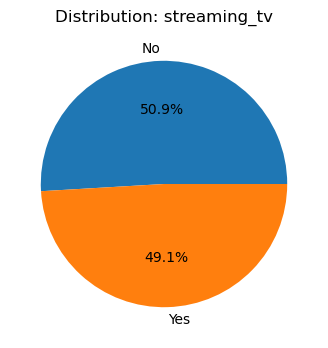


Feature: streaming_movies
Number of unique values: 2


streaming_movies
No     2785
Yes    2732
Name: count, dtype: int64

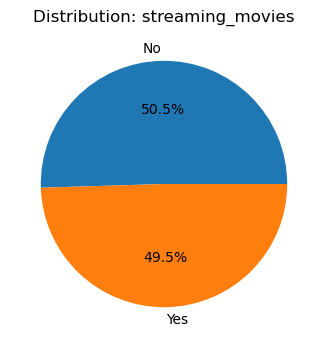

------------------------------------------------------------------------------------------------------------------------
Categorical features in table: phone
------------------------------------------------------------------------------------------------------------------------

Feature: customer_id
Number of unique values: 6361


customer_id
5575-GNVDE    1
0980-FEXWF    1
8082-GHXOP    1
3393-FMZPV    1
8701-DGLVH    1
             ..
8197-BFWVU    1
9154-QDGTH    1
8499-BRXTD    1
8552-OBVRU    1
3186-AJIEK    1
Name: count, Length: 6361, dtype: int64


Feature: multiple_lines
Number of unique values: 2


multiple_lines
No     3390
Yes    2971
Name: count, dtype: int64

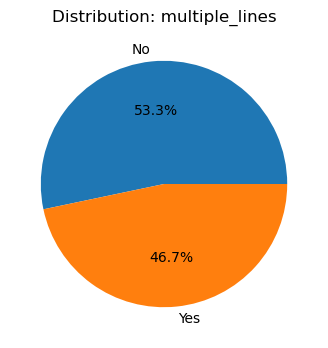

In [38]:
# apply the 'analyze_categorical' function to each dataframe
for table_name, df_table in dfs.items():
    analyze_categorical(df_table, table_name)

The analysis of categorical features revealed the following:

1. **`contract` table:**

**`type`:**
- Month-to-month - 55%
- Two year - 24.1%
- One year - 20.9%

Monthly contracts dominate the dataset, while one-year and two-year contracts have comparable shares.

**`paperless_billing`:**
- Yes - 59.2%
- No - 40.8%

The distribution is relatively balanced.

**`payment_method`:**
- Electronic check - 33.6%
- Mailed check - 22.9%
- Bank transfer (automatic) - 21.9%
- Credit card (automatic) - 21.6%

Electronic check is the most popular payment method.

2. **`personal` table:**

**`gender`:**
The distribution is nearly equal (50.5% male, 49.5% female).

**`senior_citizen`:**
- Yes - 16.2%
- No - 83.8%

There is a clear imbalance: senior citizens represent a smaller portion of customers.

**`partner`:**
The distribution is close to balanced (51.7% - No, 48.3% - Yes).

**`dependents`:**
- Yes - 30%
- No - 70%

Most customers do not have children.

3. **`internet` table:**

**`internet_service`:**
- Fiber optic - 56.1%
- DSL - 43.9%

The distribution is relatively balanced.

**Share of additional services usage:**
- online_security - 36.6%
- online_backup - 44.0%
- device_protection - 43.9%
- tech_support - 37.0%
- streaming_tv - 49.1%
- streaming_movies - 49.5%

Most customers do not use `online_security` and `tech_support`.

4. **`phone` table:**

**`multiple_lines`:**
- Yes - 46.7%
- No - 53.3%

The distribution is close to balanced.

**Key Points:**
1. The `customer_id` feature should be excluded from the training dataset.
2. All categorical features require encoding before being used in the model.

In this project, numerical features are present only in the `monthly_charges` and `total_charges` columns of the `contract` table.

In [39]:
# create a list of numerical features
numeric_cols = ['monthly_charges', 'total_charges']

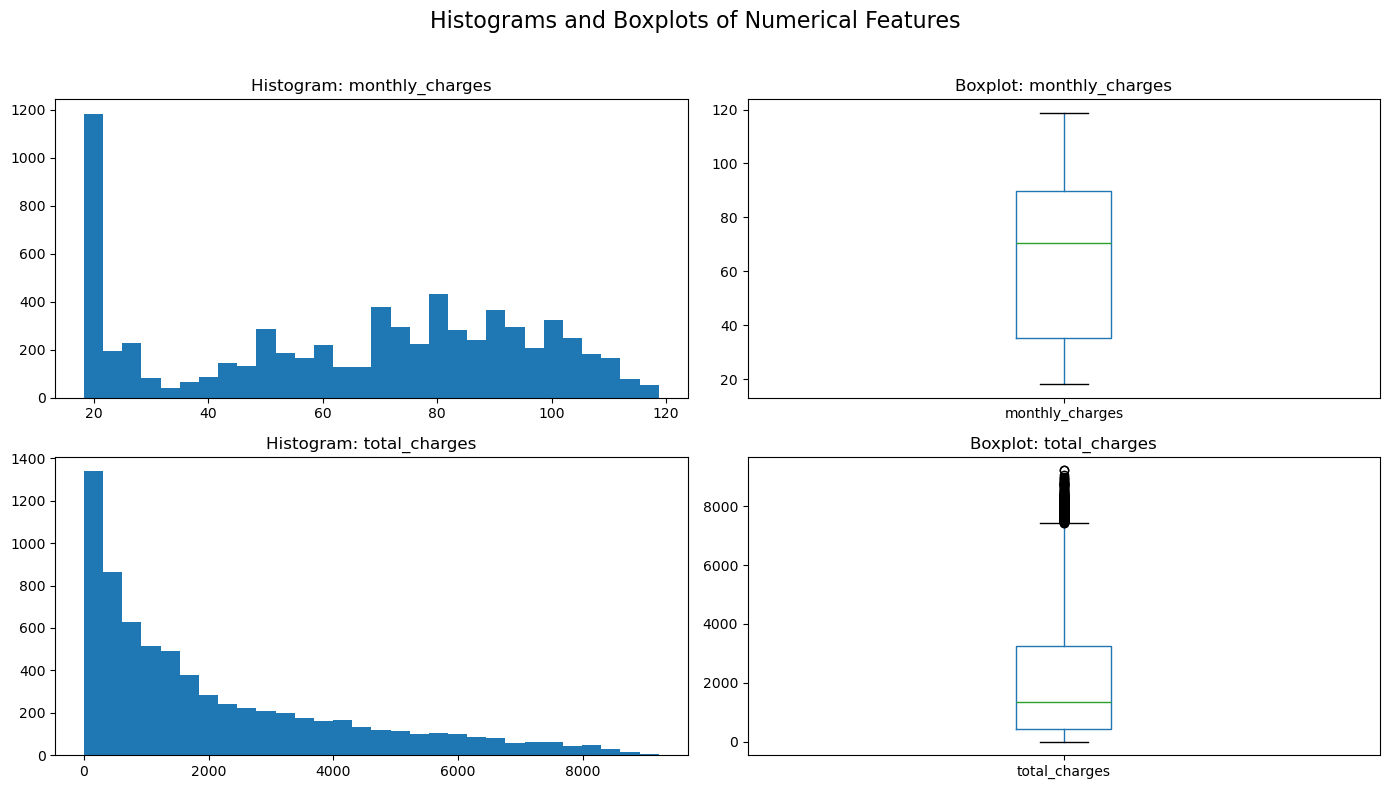

In [40]:
# plot histograms and boxplots for numerical features
n_cols = 2
n_rows = len(numeric_cols)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, 4 * n_rows))
fig.suptitle('Histograms and Boxplots of Numerical Features', fontsize=16)
axes = axes.reshape(n_rows, n_cols)

for i, col in enumerate(numeric_cols):
    # histogram
    contract[col].hist(bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram: {col}')
    axes[i, 0].grid(False)

    # boxplot
    contract[[col]].boxplot(ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot: {col}')
    axes[i, 1].grid(False)
    
plt.tight_layout(rect=[0, 0, 1, 0.96])

In [41]:
# display descriptive statistics
print("Descriptive statistics for numerical features:")
display(contract[numeric_cols].describe())

Descriptive statistics for numerical features:


,monthly_charges,total_charges
count,7043.00,7043.00
mean,64.76,2115.31
std,30.09,2112.74
min,18.25,0.00
25%,35.50,436.75
50%,70.35,1343.35
75%,89.85,3236.69
max,118.75,9221.38


The analysis of numerical features in the `contract` table revealed the following:

**`monthly_charges:`**

- Range: 18.25-118.75
- Median: 70.35
- Mean: 64.76
- The distribution is relatively uniform, with no extreme outliers.
- The boxplot does not indicate any critical anomalies.

These values are consistent with typical telecom pricing plans. No outlier treatment is required.

**`total_charges:`**

- Range: 0-9221.38
- Median: 1343.35
- Mean: 2115.31
- The distribution is heavily right-skewed.
- Some high values are observed.
- The strong right skew is explained by the cumulative nature of this feature.
- The apparent outliers are justified and should not be removed or capped, as this would distort information about long-term customers.

**Key Points:**
- No critical anomalies were found in the numerical features of the `contract` table.
- Outlier treatment is not required.
- High values (7000-9000) in `total_charges` logically correspond to long-term customers with multi-year contracts.
- It is worth verifying whether the value 0 in `total_charges` corresponds to new customers who joined on February 1, 2020, identified earlier in the analysis.

Now, let's perform an additional check for zero values in `total_charges`.

In [42]:
# inspect rows where 'total_charges' equals 0
contract.loc[contract['total_charges'] == 0, 
             ['customer_id', 'begin_date', 'end_date', 'monthly_charges', 'total_charges']]

,customer_id,begin_date,end_date,monthly_charges,total_charges
488,4472-LVYGI,2020-02-01,NaT,52.55,0.00
753,3115-CZMZD,2020-02-01,NaT,20.25,0.00
936,5709-LVOEQ,2020-02-01,NaT,80.85,0.00
1082,4367-NUYAO,2020-02-01,NaT,25.75,0.00
1340,1371-DWPAZ,2020-02-01,NaT,56.05,0.00
3331,7644-OMVMY,2020-02-01,NaT,19.85,0.00
3826,3213-VVOLG,2020-02-01,NaT,25.35,0.00
4380,2520-SGTTA,2020-02-01,NaT,20.00,0.00
5218,2923-ARZLG,2020-02-01,NaT,19.70,0.00
6670,4075-WKNIU,2020-02-01,NaT,73.35,0.00


The analysis showed that all values where `total_charges = 0` correspond to customers who had just subscribed as of the data snapshot date (`February 1, 2020`) and had not yet accumulated any charges. Therefore, a value of 0 is justified in this case (this corresponds to replacing empty strings with zero, which was performed earlier).

All categorical and numerical features across the four tables have now been examined. We can now proceed to join them into a single unified dataframe, which will be used for further analysis and model training.

### Creating a Unified DataFrame

Next, we will join the tables into a single dataframe using the customer identifier, ensuring that each customer corresponds to exactly one row. The `contract` table will be used as the base, since it contains all customers, while the `internet` and `phone` tables include only those who have subscribed to the respective services.

In [43]:
# join (merge) tables by 'customer_id' into a single dataframe
# 'contract' is the base table, so we use left join
data = (
    contract
    .merge(personal, on='customer_id', how='left')
    .merge(internet, on='customer_id', how='left')
    .merge(phone, on='customer_id', how='left')
)

In [44]:
# check the final size of the dataframe after merging all tables
print("Final shape after merging all tables:", data.shape)

Final shape after merging all tables: (7043, 20)


In [45]:
# check that each customer corresponds to exactly one row
print("Unique customer_id:", data['customer_id'].nunique())
print("Number of rows in data:", len(data))

Unique customer_id: 7043
Number of rows in data: 7043


In [46]:
# check for duplicate 'customer_id' values
dup_cnt = data.duplicated(subset=['customer_id']).sum()
print("Number of duplicate customer_id:", dup_cnt)

Number of duplicate customer_id: 0


In [47]:
# check for missing values after merging
print("Missing values after merging:")
display(data.isna().sum().sort_values(ascending=False).head(10))

Missing values after merging:


end_date             5942
streaming_movies     1526
streaming_tv         1526
tech_support         1526
device_protection    1526
online_backup        1526
online_security      1526
internet_service     1526
multiple_lines        682
dependents              0
dtype: int64

In [48]:
# display the first rows of the unified dataframe
data.head(2)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,Female,No,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,Male,No,No,No,DSL,Yes,No,Yes,No,No,No,No


The tables were successfully merged into a single dataframe with a size of `7043 rows and 20 columns`. Each client corresponds to exactly one observation (the number of rows matches the number of unique `customer_id` values), and no duplicates are present. Missing values appear only in features related to internet and phone services, which is logically explained by the fact that not all customers use these services.

The unified dataset has been successfully created. And now, we can proceed to its analysis.

### Analysis and Preprocessing of the Unified Dataset

#### Target Variable Creation

Next, we will define the target variable `churn` based on the `end_date` column.

In [49]:
# create the target variable 'churn'
data['churn'] = data['end_date'].notna().astype(int)

In [50]:
# check the distribution
print("Churn distribution:")
print(data['churn'].value_counts())

Churn distribution:
churn
0    5942
1    1101
Name: count, dtype: int64


In [51]:
# check the proportion of churned customers
print("Proportion of churned customers:")
print(data['churn'].value_counts(normalize=True))

Proportion of churned customers:
churn
0   0.84
1   0.16
Name: proportion, dtype: float64


The target variable `churn` has been created: `1101 customers (16%) have left`, while `5942 customers (84%) remain active` at the reference date of the dataset. A class imbalance is observed, however, it is not critical and can be handled during model training, for example, by using stratification or the `class_weight` parameter.

#### Feature Engineering

In the further analysis, we may benefit from additional features derived from the existing ones, such as `contract duration` and `the number of subscribed services`. Let's begin by creating the feature `contract duration`.

Since the data is up to date as of February 1, 2020, for active customers (where `end_date = NaT`), this date is treated as the contract end date.

In [52]:
# set the reference date for the dataset
current_date = pd.to_datetime('2020-02-01')

In [53]:
# if end_date = NaT, replace with current_date
data['contract_end_filled'] = data['end_date'].fillna(current_date)

In [54]:
# calculate contract duration in days
data['contract_duration_days'] = (
    data['contract_end_filled'] - data['begin_date']
).dt.days

In [55]:
# check the result
data[['begin_date', 'end_date', 'contract_duration_days']].head(2)

,begin_date,end_date,contract_duration_days
0,2020-01-01,NaT,31
1,2017-04-01,NaT,1036


In [56]:
# check the distribution of the new feature 'contract_duration_days'
data['contract_duration_days'].describe()

count   7043.00
mean     898.56
std      683.13
min        0.00
25%      276.00
50%      761.00
75%     1461.00
max     2314.00
Name: contract_duration_days, dtype: float64

The distribution appears reasonable: the average contract duration is approximately `899 days` (about 2.5 years), with a median of `761 days`, indicating that a significant portion of customers have been with the company for more than two years. The minimum value of `0 days` corresponds to new customers who joined on `February 1, 2020`. No anomalies were detected.

Now let’s create another potentially useful feature: the `number of subscribed services`. It is reasonable to assume that the more services a customer uses, the lower the likelihood of churn. This serves as a strong behavioral indicator of customer engagement.

In [57]:
# create a list of features representing services
service_cols = [
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies',
    'multiple_lines'
]

In [58]:
# count the number of services with the value 'Yes'
data['num_services'] = (
    data[service_cols] == 'Yes'
).sum(axis=1)

In [59]:
# check the distribution of the new feature 'num_services'
data['num_services'].describe()

count   7043.00
mean       2.46
std        2.05
min        0.00
25%        1.00
50%        2.00
75%        4.00
max        7.00
Name: num_services, dtype: float64

On average, a customer uses `2-3 services`. At the same time, there are customers with no additional services `(0)` as well as those who have subscribed to all `7 available services`. The distribution appears realistic and reflects different levels of customer engagement. This feature is logically justified and may play an important role in the model, as higher engagement is often associated with a lower likelihood of churn.

#### EDA of Categorical Features

Now that the data has been merged and the target variable and additional features have been created, we can move on to exploratory data analysis and correlation analysis.

Let's start by checking for missing values.

In [60]:
# check missing values
na_summary = data.isna().sum().sort_values(ascending=False)
display(na_summary[na_summary > 0])

end_date             5942
internet_service     1526
online_security      1526
streaming_movies     1526
streaming_tv         1526
tech_support         1526
device_protection    1526
online_backup        1526
multiple_lines        682
dtype: int64

As observed earlier, missing values are present only in features related to internet and phone services. This is logically explained by the fact that not all customers subscribed to these services. A special note should be made for the `end_date` feature. Missing values in this column (`5942`) indicate that the contract was still active as of the data snapshot date (`February 1, 2020`). Therefore, these are not truly missing values but rather an indicator of currently active customers. Thus, all identified missing values have a structural nature and are not data errors.

For internet-related features, missing values are replaced with `'No'`, reflecting the absence of the corresponding service.

For the `multiple_lines` feature, a separate category `'No phone service'` is used to avoid mixing customers with a single phone line and those who do not have phone service at all.

In [61]:
# create a list of internet-related features
internet_cols = [
    'internet_service', 'online_security', 'online_backup',
    'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies'
]

In [62]:
# if there is no record in the internet table, it means the service is not used
# so we fill missing values with 'No'
data[internet_cols] = data[internet_cols].fillna('No')

In [63]:
# if there is no row in the phone table, it means the customer does not have phone service
# therefore, we assign it to a separate category
data['multiple_lines'] = data['multiple_lines'].fillna('No phone service')

In [64]:
# check the distribution of values after filling missing values
print(data['multiple_lines'].value_counts(dropna=False))

multiple_lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


After handling missing values, most customers fall into two groups: those who have one line (`No`) and those who have multiple lines (`Yes`). A smaller group of 682 customers is explicitly marked as `No phone service`, indicating that they do not use telephone services at all.

In [65]:
# check missing values after handling
print("Missing values after processing:")
display(data.isna().sum().sort_values(ascending=False).head())

Missing values after processing:


end_date                  5942
customer_id                  0
online_security              0
contract_duration_days       0
contract_end_filled          0
dtype: int64

Thus, missing values in the internet and phone service features have been fully handled. The only remaining missing values are in `end_date`, which correspond to contracts that were still active at the time of data extraction and therefore do not represent data errors. Next, we will visualize the distributions of categorical features and examine their relationship with the target variable `churn`.

In [66]:
# create a function to plot the distribution of a categorical feature and its relationship with 'churn'
def plot_feature_vs_churn(df, col):
    """
    Plots the distribution of a categorical feature and its relationship with churn.
    """
    # plot the feature distribution and churn rate for each category
    plt.figure(figsize=(8,4))
    
    # feature value distribution
    plt.subplot(1,2,1)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution: {col}')
    plt.xticks(rotation=45)
    
    # relationship with 'churn'
    plt.subplot(1,2,2)
    sns.barplot(data=df, x=col, y='churn')
    plt.title(f'Churn rate by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

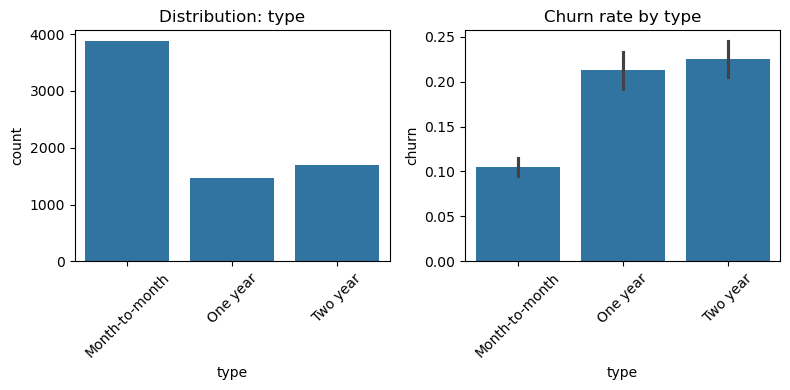

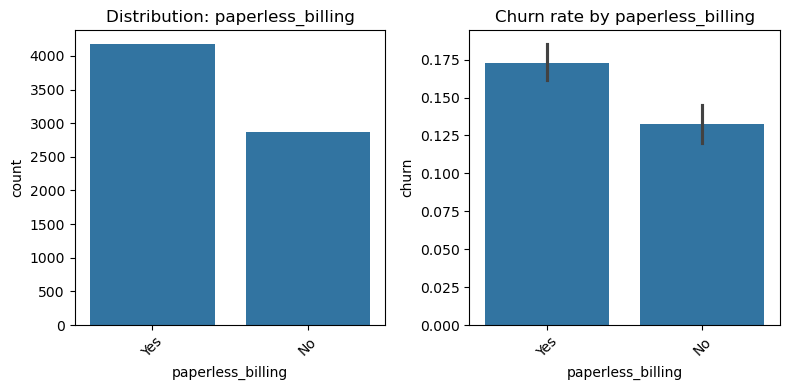

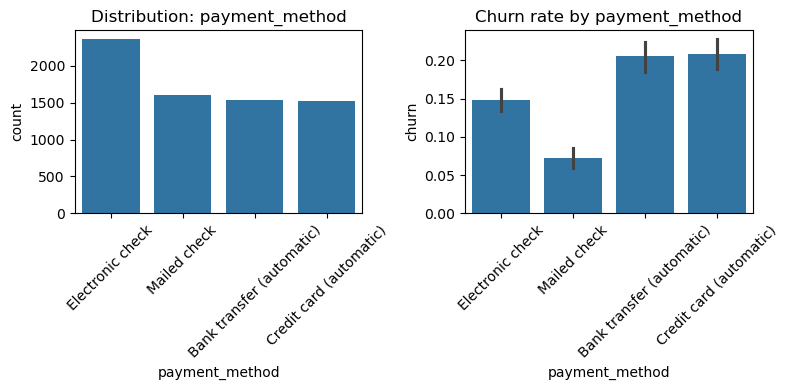

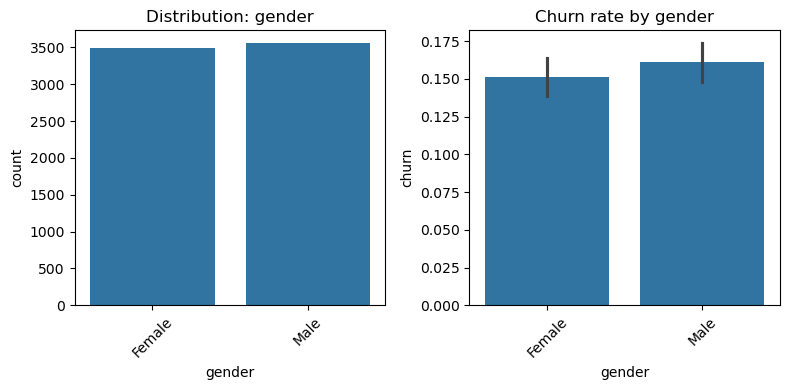

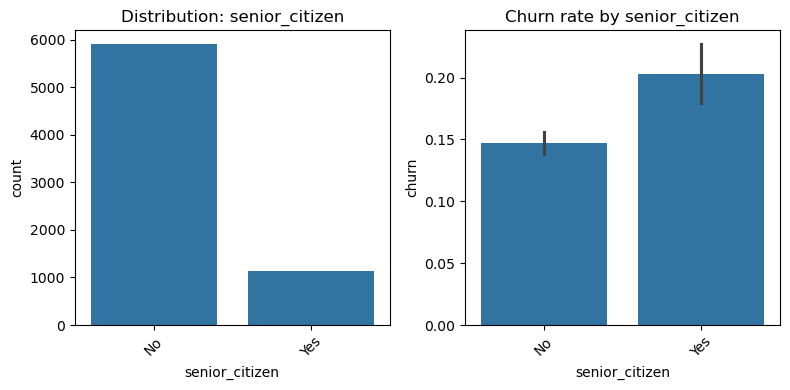

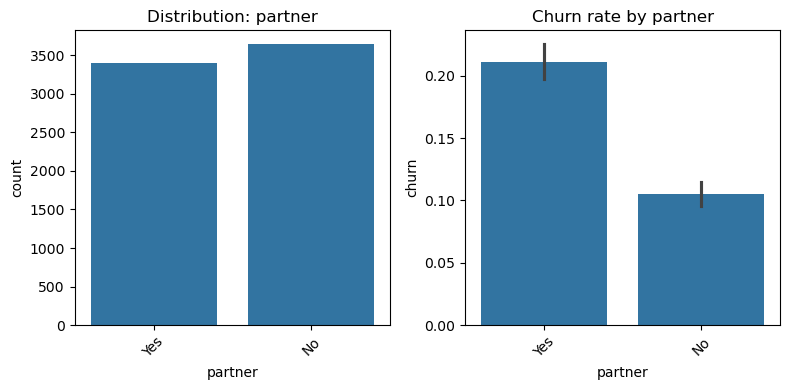

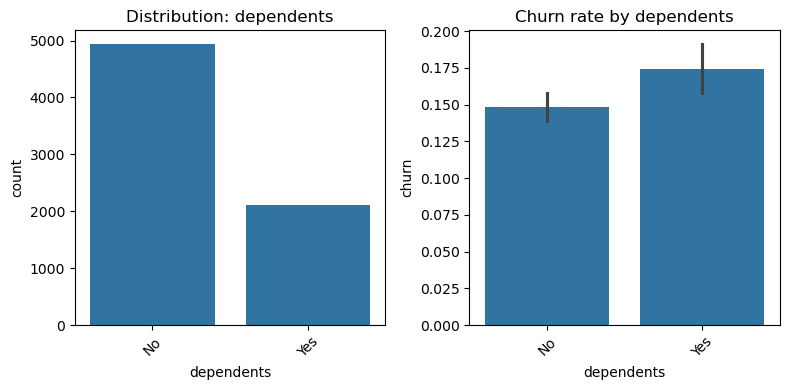

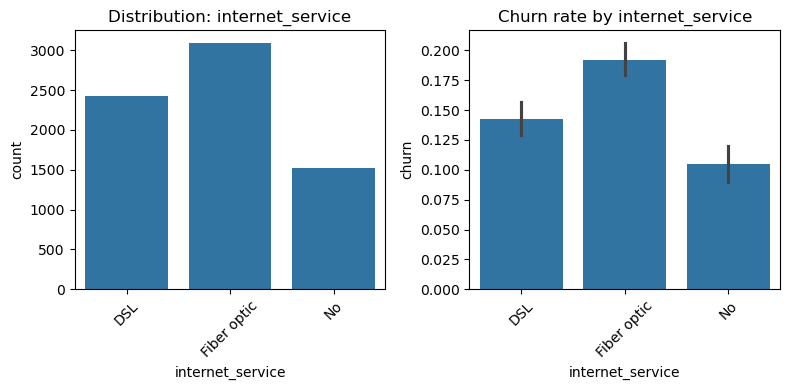

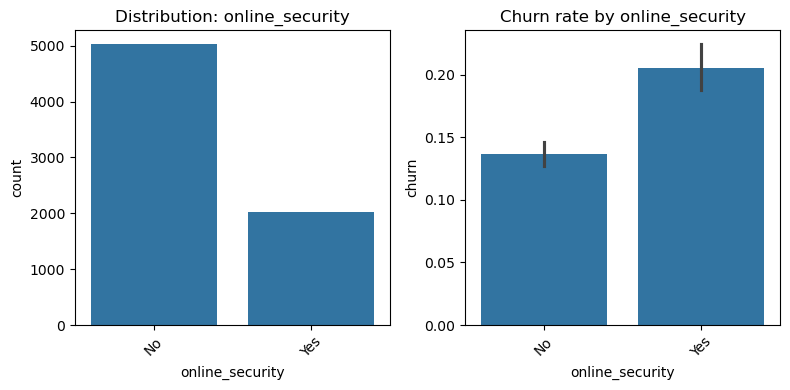

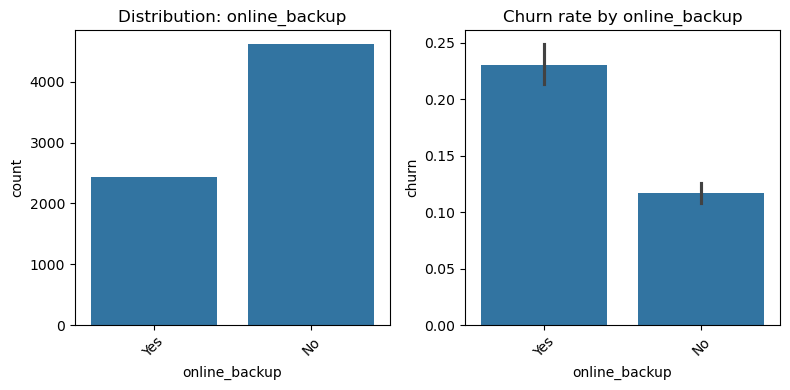

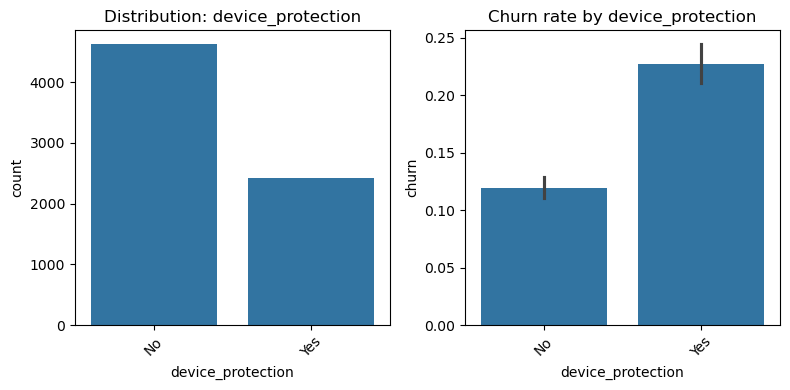

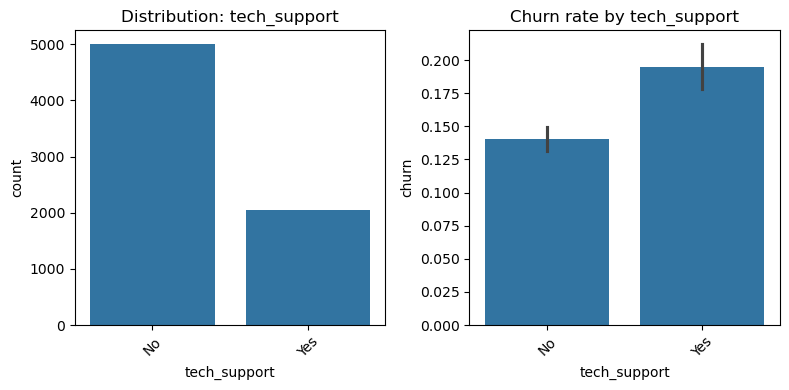

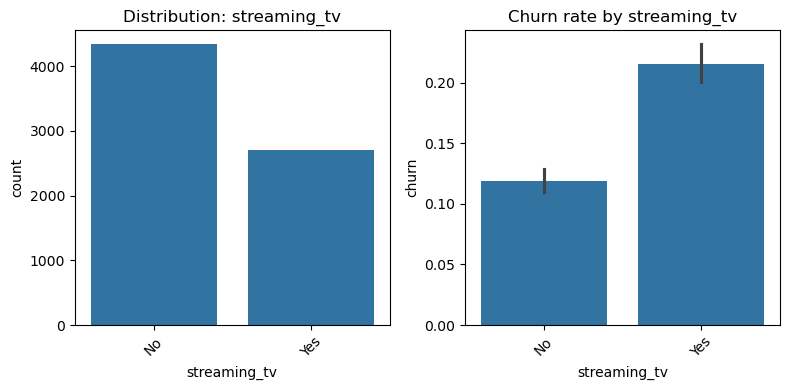

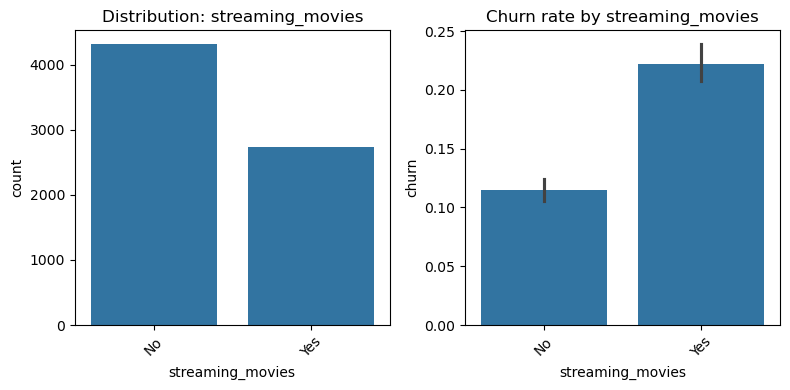

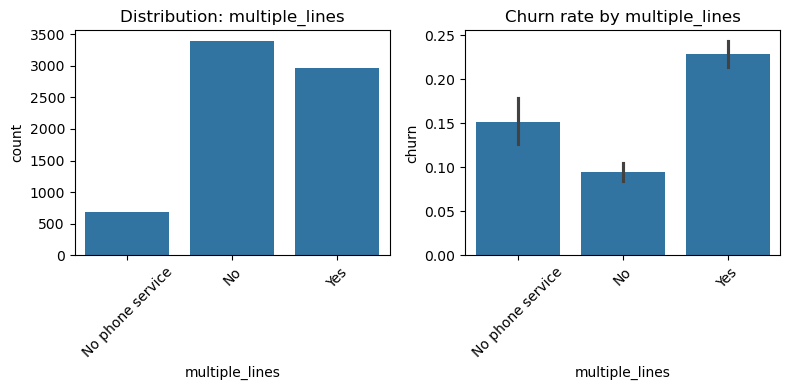

In [67]:
# apply the 'plot_feature_vs_churn' function to categorical features
categorical_cols = data.select_dtypes(include='object').columns
categorical_cols = [col for col in categorical_cols if col != 'customer_id']
for col in categorical_cols:
    plot_feature_vs_churn(data, col)

The analysis of categorical features showed the following:

**type:** the most common contract type is monthly payment. Annual and two-year contracts are significantly less frequent. At the same time, the churn rate among monthly customers is lower (around 10%), while among customers with annual and two-year contracts it is higher (around 21-22%).

**paperless_billing:** most customers use electronic billing. The churn rate among such customers is higher (around 17%) compared to customers receiving paper bills (around 13%).

**payment_method:** the most common payment method is electronic check. The lowest churn rate is observed among customers using mailed check (around 7%). For other payment methods, churn is higher: around 15% for electronic check and 20-21% for automatic payments (bank transfer and credit card).

**gender:** the number of male and female customers is approximately equal. The churn rate is almost identical for both groups (around 15-16%).

**senior_citizen:** most customers are not senior citizens. However, the churn rate among senior citizens is higher (around 20%) compared to non-seniors (around 15%).

**partner:** the number of customers with and without a partner is comparable. Customers with a partner show a higher churn rate (around 21%) compared to those without (around 10%).

**dependents:** most customers do not have children. The churn rate among customers with children is higher (around 17%) than among those without (around 14%).

**internet_service:** the most common type of connection is fiber optic. The lowest churn rate is observed among customers without internet service (around 10%). Among DSL users, churn is higher (around 14%), and among fiber optic users it is the highest (around 19%).

**online_security:** most customers do not use the online security service. The churn rate among users of this service is higher (around 20%) than among non-users (around 13-14%).

**online_backup:** most customers do not use the backup service. The churn rate among users is higher (around 23%) compared to non-users (around 11-12%).

**device_protection:** most customers do not use device protection. The churn rate among users is higher (around 22-23%) than among non-users (around 12%).

**tech_support:** most customers do not use technical support. The churn rate among users is higher (around 19%) than among non-users (around 14%).

**streaming_tv:** most customers do not use streaming TV. The churn rate among users is higher (around 21-22%) than among non-users (around 12%).

**streaming_movies:** most customers do not use streaming movies. The churn rate among users is higher (around 22-23%) than among non-users (around 11-12%).

**multiple_lines:** most customers either have a single line or multiple lines, while a smaller group does not use phone services at all. The highest churn rate is observed among customers with multiple lines (around 22-23%), followed by customers without phone service (around 15%), while the lowest churn rate is among customers with a single line (around 9%).

**Key Points:**

Based on the analysis, several features appear to be more informative for churn prediction. The most noticeable differences in churn rates are observed for `type`, `payment_method`, `internet_service`, and several additional services (`online_backup`, `device_protection`, `streaming_tv`, `streaming_movies`, `multiple_lines`). 

At the same time, features such as `gender` show almost identical churn rates across categories and are likely to be less informative. These conclusions are initial and based only on visual analysis. A more detailed evaluation of feature impact will follow after model training during the feature importance analysis.

#### EDA of Numerical Features

Next, we will analyze the numerical features of the unified dataset.

In [68]:
# create a list of numerical features
numeric_cols = [
    'monthly_charges',
    'total_charges',
    'contract_duration_days',
    'num_services'
]

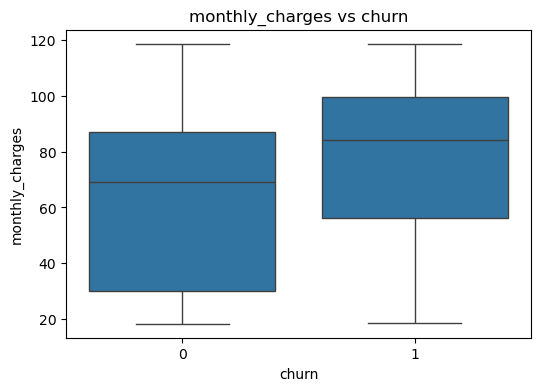

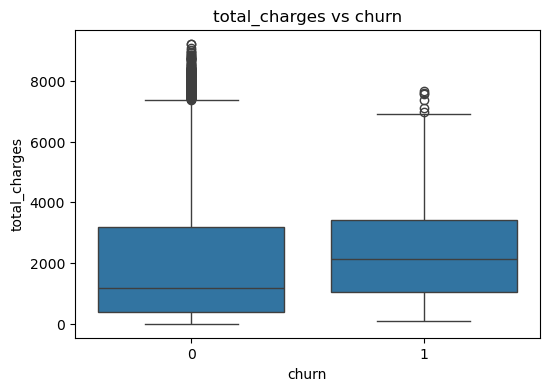

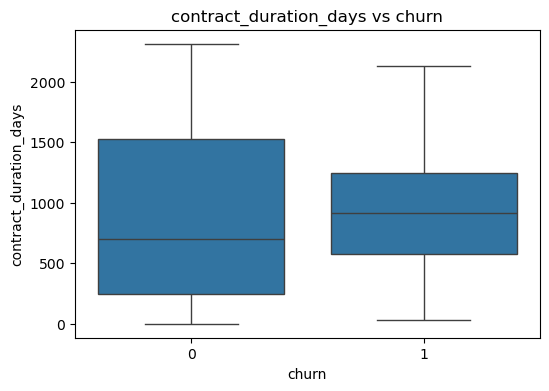

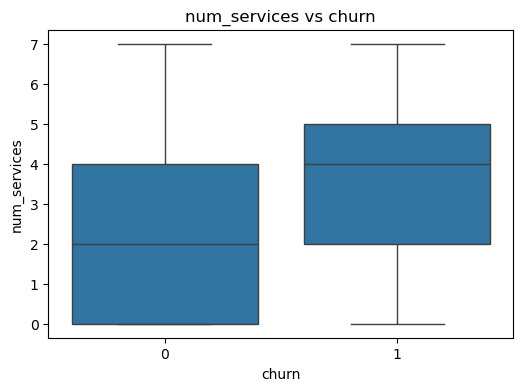

In [69]:
# visualize the distribution of numerical features by 'churn'
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x='churn', y=col)
    plt.title(f'{col} vs churn')
    plt.show()

The analysis of numerical features revealed the following:

**monthly_charges:** customers who churned (churn = 1) have a higher median monthly charge compared to those who stayed (churn = 0). The distribution of `monthly_charges` for churned customers is shifted toward higher values, while retained customers tend to have more values in the lower range.

**total_charges:** the total charges span a wide range in both groups. However, the median `total_charges` is higher for customers who churned than for those who continue using the services.

**contract_duration_days:** customers who churned have a higher median contract duration than those who stayed. Although the distributions overlap, shorter contract durations are more common among retained customers.

**num_services:** customers who churned have a higher median number of subscribed services. The distribution of `num_services` for churned customers is shifted toward higher values, while active customers more often have fewer services.

**Key Points:**

The analysis of numerical features shows noticeable differences between churn groups. The most pronounced differences are observed for `monthly_charges` and `num_services`, where churned customers have higher median values. The features `total_charges` and `contract_duration_days` also demonstrate some separation between groups. Overall, all these features appear to be potentially useful for churn prediction.

#### Correlation Analysis

Next, we will move on to a correlation analysis of the unified dataframe. We will use phik-correlation, since the dataset contains many categorical and binary features, making classical Pearson correlation less appropriate. Before performing the correlation analysis, it is necessary to remove features that directly contain information about contract termination. The features `end_date` and `contract_end_filled` include information used to construct the target variable `churn`, so including them in the analysis could lead to biased results. Additionally, the feature `customer_id` should be excluded, as it is a technical identifier and does not provide any meaningful information about customer behavior or characteristics.

In [70]:
# check dataframe shape before dropping features
print("Dataframe shape before dropping features:", data.shape)

Dataframe shape before dropping features: (7043, 24)


In [71]:
# remove features that are not included in the correlation analysis
corr_data = data.drop(columns=['end_date', 'contract_end_filled', 'customer_id'])

In [72]:
# check the dataframe shape after dropping features
print("Dataframe shape after dropping features:", corr_data.shape)

Dataframe shape after dropping features: (7043, 21)


In [73]:
# calculate phik correlation matrix
phik_corr = corr_data.phik_matrix()

interval columns not set, guessing: ['monthly_charges', 'total_charges', 'churn', 'contract_duration_days', 'num_services']


In [74]:
# display feature correlations with 'churn'
phik_churn = phik_corr['churn'].sort_values(ascending=False)
print("Feature correlations with churn (phik):")
display(phik_churn)

Feature correlations with churn (phik):


churn                    1.00
begin_date               0.45
contract_duration_days   0.37
total_charges            0.30
num_services             0.29
online_backup            0.23
partner                  0.23
monthly_charges          0.23
streaming_movies         0.22
device_protection        0.22
payment_method           0.21
streaming_tv             0.20
online_security          0.13
multiple_lines           0.11
tech_support             0.10
type                     0.09
senior_citizen           0.09
paperless_billing        0.08
internet_service         0.06
dependents               0.05
gender                   0.01
Name: churn, dtype: float64

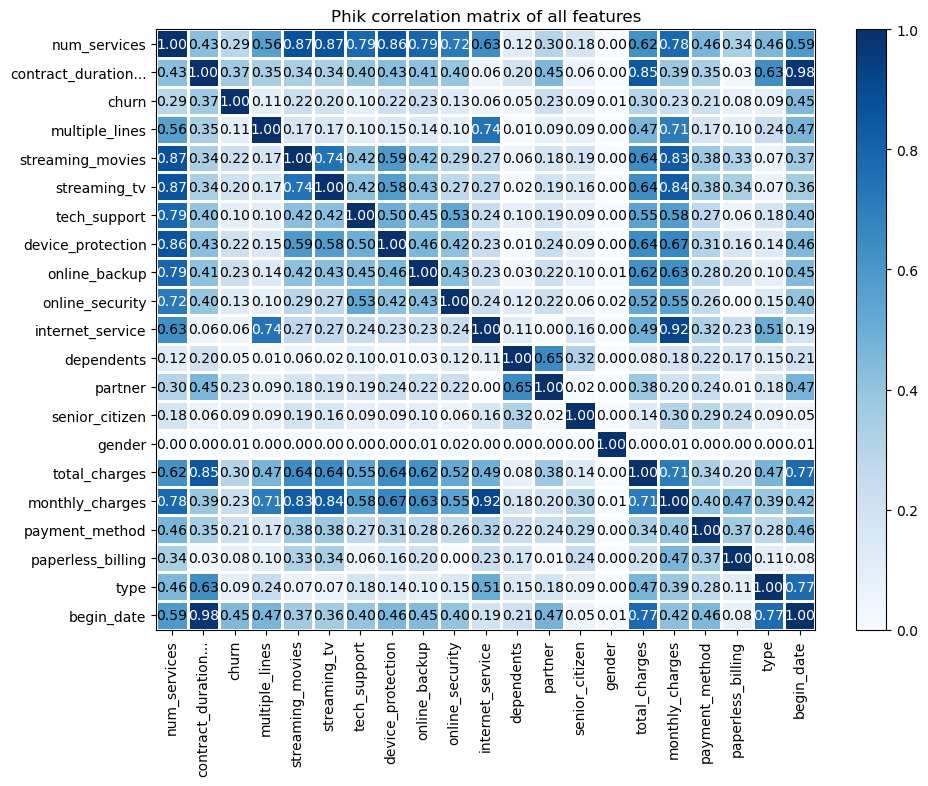

In [75]:
# plot the correlation matrix
plot_correlation_matrix(
    phik_corr.values,
    x_labels=phik_corr.columns,
    y_labels=phik_corr.index,
    figsize=(10, 8),
    vmax=1,
    vmin=0,
    color_map="Blues")
plt.title('Phik correlation matrix of all features', fontsize=12)
plt.show()

The correlation analysis showed the following results.

**Relationship between features and churn:** the strongest relationships with the target variable are observed for the following features:

- `begin_date`- 0.45
- `contract_duration_days`- 0.37
- `total_charges`- 0.30
- `num_services`- 0.29
- `online_backup`, `partner`, `monthly_charges`- 0.23

The strongest relationships are observed for features related to customer tenure (`begin_date`, `contract_duration_days`). This suggests that the duration of a customer's interaction with the operator is an important factor in churn.

Features reflecting service usage (`num_services`, `online_backup`) show a moderate relationship with `churn`. This may indicate that the type and intensity of service usage are associated with the likelihood of customer churn.

Financial indicators (`monthly_charges`, `total_charges`) also demonstrate a moderate relationship with `churn`, suggesting that churn may depend on the customer's level of expenses.

**Features with low correlation to churn:** socio-demographic characteristics show a weak relationship with the target variable:

- `gender`- 0.01
- `dependents`- 0.05
- `senior_citizen`- 0.09

This indicates that demographic characteristics have little impact on the likelihood of customer churn.

**Relationships between features:**

The correlation matrix also reveals relationships between some features. For example, `begin_date` and `contract_duration_days` capture similar information about customer tenure. When training the model, it is important to consider potential redundancy between such features.

**Key Points:**

- The correlation analysis shows that the strongest relationships with churn are observed for features related to customer tenure (`begin_date`, `contract_duration_days`), financial indicators (`total_charges`, `monthly_charges`), and service engagement (`num_services`, `online_backup`).
- At the same time, demographic features (`gender`, `dependents`, `senior_citizen`) demonstrate minimal correlation with `churn`.
- It is important to note that overall correlation values are moderate (not exceeding 0.45), which is typical for real-world business data and indicates the absence of a single dominant factor driving churn. A more precise evaluation of feature influence will be performed during the feature importance analysis after model training.

Additionally, we will analyze multicollinearity among numerical features using standard correlation.

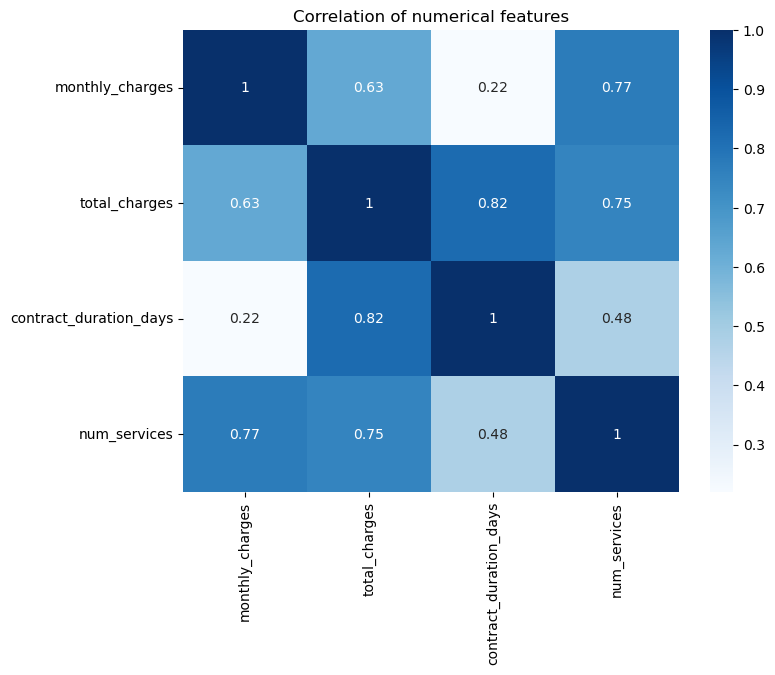

In [76]:
# calculate and plot the correlation matrix for numerical features
corr_matrix = data[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title("Correlation of numerical features")
plt.show()

The matrix shows the presence of strong linear relationships between several numerical features. For example, `total_charges` has a strong correlation with the contract duration `contract_duration_days` (0.82) and a moderate correlation with `monthly_charges` (0.63), which can be explained by the cumulative nature of total payments.

A high correlation is also observed between `monthly_charges` and `num_services` (0.77). This is consistent with the business logic: the more services a customer uses, the higher their monthly payment.

The feature `num_services` also shows a moderate correlation with `total_charges` (0.75), which can be explained by the fact that a larger number of connected services leads to higher accumulated costs over time.

The correlation between `contract_duration_days` and `num_services` is moderate (0.48), which may indicate that customers with longer service durations are more likely to subscribe to additional services.

**Key Points:**

The analysis of numerical features reveals several strong relationships between variables. The most pronounced dependencies are observed between `total_charges` and `contract_duration_days`, as well as between `monthly_charges` and `num_services`.

This suggests partial redundancy among some features, as they reflect closely related aspects of customer behavior (spending level and service usage intensity). However, these features describe different dimensions of customer activity (monthly payments, accumulated charges, service duration, and number of services), so they are retained at this stage for model training. Their final importance and the need for possible removal will be assessed after model training during the feature importance analysis stage.

### Data Preparation for Model Training

Before training the model, it is necessary to determine which features will be used for prediction and which do not carry useful information or may lead to biased results. For further modeling, all features will be used except for the following:

- The feature `customer_id` is a technical identifier of the client and does not contain information about their behavior or characteristics, therefore it cannot be used as a predictor.
- The feature `begin_date` contains the calendar start date of the contract. Using the raw date does not provide meaningful analytical value for the model, as it does not directly reflect customer behavior. At the same time, information about the duration of the contract is already captured in the engineered feature `contract_duration_days`.
- The features `end_date` and `contract_end_filled` contain information about the contract termination. Since the target variable `churn` was derived from these features, using them in model training would lead to target leakage.

Based on this, we will create the feature matrix `X` and the target variable `y` for further model training.

In [77]:
# define the list of input features
features = [
    'monthly_charges',
    'total_charges',
    'contract_duration_days',
    'num_services',
    'type',
    'payment_method',
    'paperless_billing',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'multiple_lines',
    'gender',
    'senior_citizen',
    'partner',
    'dependents'
]

In [78]:
# create the feature matrix X and the target variable y
X = data[features]
y = data['churn']

In [79]:
# check the shapes of the resulting datasets
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (7043, 19)
Shape of y: (7043,)


The datasets have been prepared correctly and are ready to be split into training and test sets. According to the task requirements, `25% of the data` will be allocated to the test set (`test_size=0.25`), which will be used for the final evaluation of the model.

The split is performed using the `stratify=y` parameter, which ensures that the distribution of the target variable `churn` remains consistent in both the training and test sets. This is particularly important given the existing class imbalance, as it allows the model to be trained and evaluated on datasets with the same target distribution.

To ensure reproducibility of the results, the `RANDOM_STATE` parameter is set to `20326`.

In [80]:
# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE)

In [81]:
# check the sizes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5282, 19)
X_test shape: (1761, 19)


In [82]:
# check the proportion of each class in the train set
print("Churn proportion in train:")
print(y_train.value_counts(normalize=True))

Churn proportion in train:
churn
0   0.84
1   0.16
Name: proportion, dtype: float64


In [83]:
# check the proportion of each class in the test set
print("Churn proportion in test:")
print(y_test.value_counts(normalize=True))

Churn proportion in test:
churn
0   0.84
1   0.16
Name: proportion, dtype: float64


The data has been successfully split into training and test sets. The proportion of the target variable `churn` is preserved in both sets due to stratified splitting, which helps avoid class imbalance distortion. The sizes of the datasets match the specified parameters. The data is now ready for model training.

**Summary**

<div style="border:solid lightblue 3px; padding: 20px">

In this section, EDA and preprocessing were performed to prepare the data for model training.

**Analysis and preprocessing of each table:**
- The structure of the initial data and the number of tables were verified to match the project requirements.
- Both categorical and numerical features in each table were analyzed, including their distributions and potential anomalies.
- Column names were standardized to a unified format (`snake_case`), and data types were corrected (dates and numerical features).
- Not all customers use internet or phone services, which was taken into account during table joining.

**Creation of a unified dataframe:**
- The tables were joined using the `customer_id` key, with the `contract` table as the base.
- As a result, a unified dataframe of size `7043 × 20` was created, where each row corresponds to a single customer.
- Missing values in internet and phone-related features were explained by the absence of those services for some customers and were not treated as data errors.

**Analysis and preprocessing of the unified dataframe:**
- The target variable `churn` was created based on the `end_date` feature: the proportion of churned customers is around `16%`, indicating a moderate class imbalance.
- Additional features were engineered: contract duration (`contract_duration_days`) and number of subscribed services (`num_services`).
- Exploratory analysis of categorical features revealed variables potentially associated with churn (`type`, `payment_method`, `internet_service`, and additional service features).
- Numerical features were analyzed, showing the most noticeable differences between churned and retained customers for `monthly_charges`, `total_charges`, `contract_duration_days`, and `num_services`.
- Correlation analysis was performed using the `phik correlation`, which allows handling categorical and binary variables.
- It was found that churn is most strongly associated with `service duration, customer spending, and usage of additional services`, while `demographic features` have minimal impact.
- Some dependencies between numerical features were also identified (for example, between `total_charges` and `contract_duration_days`, and between `monthly_charges` and `num_services`), reflecting the business logic of cost accumulation and service usage.

**Data preparation for modeling:**
- Features `customer_id`, `begin_date`, `end_date`, and `contract_end_filled` were removed as they are either technical identifiers or contain information related to the target variable.
- The feature matrix `X` and target variable `y` were created.
- The data was split into training and test sets in a `75/25 ratio` using stratified splitting (`stratify=y`) to preserve the class distribution.
- For reproducibility, a fixed parameter `RANDOM_STATE = 20326` was used.

Thus, the data was cleaned, analyzed, and properly prepared for the modeling stage.

## Model Training

### Model Selection

To solve the binary classification problem, we will consider several models that are well-suited for tabular data and capable of capturing nonlinear relationships between features. As a baseline to assess model adequacy, we will additionally use `DummyClassifier`. This model does not learn real patterns but serves as a simple reference point for comparison with more complex algorithms. This allows us to verify that using Random Forest, boosting, and neural networks is justified.

As the main models, we select the following families of algorithms:

- `RandomForestClassifier` - robust to noise and outliers, performs well on tabular data, and can capture nonlinear relationships and feature interactions, making it a reliable baseline ensemble method.
- `CatBoostClassifier` - one of the strongest boosting algorithms for tabular data, handles categorical features effectively, and often achieves high performance in classification tasks.
- `MLPClassifier` - a neural network capable of modeling complex nonlinear relationships. Although such models often underperform compared to boosting methods on tabular data, they are useful as an alternative class of algorithms for comparison.

### Baseline Model Training

To ensure a fair comparison of models, we will use a unified approach to training and evaluation. Model performance is assessed using the `ROC-AUC` metric, as this is a binary classification task with a moderate class imbalance, and the metric effectively reflects the model’s ability to distinguish between customers who are likely and unlikely to churn.

Model evaluation is performed using `StratifiedKFold`, which preserves the distribution of the target variable in each fold and provides a more stable and reliable estimate of model performance.

First, we will compare the baseline versions of the models using cross-validation, including a simple baseline model, `DummyClassifier`. Then, for the most promising models, we will perform hyperparameter tuning to demonstrate how model performance improves compared to the baseline configuration and to justify the choice of final parameters.

In [84]:
# define cross-validation parameters
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [85]:
# define feature groups
numeric_features = ['monthly_charges', 'total_charges', 'contract_duration_days', 'num_services']
categorical_features = [col for col in X.columns if col not in numeric_features]
print("Numeric features:", numeric_features)
print("-" * 150)
print("Categorical features:", categorical_features)

Numeric features: ['monthly_charges', 'total_charges', 'contract_duration_days', 'num_services']
------------------------------------------------------------------------------------------------------------------------------------------------------
Categorical features: ['type', 'payment_method', 'paperless_billing', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines', 'gender', 'senior_citizen', 'partner', 'dependents']


We will create a function to calculate the ROC-AUC metric using cross-validation in order to evaluate model performance. For most models, the standard `cross_val_score` function is used. For the CatBoost model, a custom cross-validation procedure is implemented to correctly pass the list of categorical features during training.

In [86]:
# create a function to compute ROC-AUC using cross-validation
def cv_roc_auc(estimator, X_data, y_data, cv, model_name, cat_features=None):
    """
    Computes ROC-AUC using cross-validation.
    """
    if cat_features is None:
        scores = cross_val_score(
            estimator,
            X_data,
            y_data,
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1
        )
        return scores

    # manual cross-validation for CatBoost
    scores = []
    for train_idx, valid_idx in cv.split(X_data, y_data):
        X_train_fold = X_data.iloc[train_idx]
        y_train_fold = y_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_valid_fold = y_data.iloc[valid_idx]
        est = clone(estimator)
        est.fit(X_train_fold, y_train_fold, cat_features=cat_features)
        proba = est.predict_proba(X_valid_fold)[:, 1]
        scores.append(roc_auc_score(y_valid_fold, proba))

    return np.array(scores)

Next, we will create two versions of the feature preprocessing pipeline. In both cases, missing values in numerical features are filled with the median, while categorical features are filled with the most frequent value and then encoded using `One-Hot Encoding`. In the second version, numerical features are additionally scaled, which is necessary for models that are sensitive to the scale of features.

In [87]:
# preprocessing for sklearn models (RandomForest and MLP)
# pipeline without scaling: suitable for tree-based models (RandomForest), which are insensitive to feature scaling
preprocess_ohe = ColumnTransformer(
    transformers=[
        # numerical features: fill missing values with median
        ('num', SimpleImputer(strategy='median'), numeric_features),

        # categorical features: fill missing values and apply OHE
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)
# pipeline with scaling: required for models sensitive to feature scale (MLP)
preprocess_ohe_scaled = ColumnTransformer(
    transformers=[
        # numerical features: imputation + standardization
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),

        # categorical features: same processing as above
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

Next, we will create a dictionary of models that will be used for baseline comparison. It will include a simple baseline model, `DummyClassifier`, as well as `RandomForest`, `MLP`, and `CatBoost`. For `RandomForest` and `MLP`, we will build pipelines that include both preprocessing steps and the model itself. `CatBoost` will be used separately, as it can handle categorical features without prior encoding.

At this stage, we will use default model configurations, while hyperparameter tuning will be performed separately in the next step.

In [88]:
# define baseline and base models for comparison
# DummyClassifier is used as a baseline to assess whether complex models provide real value
models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),

    # RandomForest with preprocessing (imputation + OHE for categorical features)
    'RandomForest': Pipeline(steps=[
        ('preprocess', preprocess_ohe),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced'
        ))
    ]),

    # MLP requires scaled numerical features, hence a separate preprocessing pipeline
    'MLP': Pipeline(steps=[
        ('preprocess', preprocess_ohe_scaled),
        ('model', MLPClassifier(
            max_iter=300,
            random_state=RANDOM_STATE
        ))
    ]),

    # CatBoost handles categorical features natively, so no OHE is required
    'CatBoost': CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=RANDOM_STATE,
        verbose=0
    )
}

Next, we will prepare separate versions of the training and test datasets for the CatBoost model. Since CatBoost can work with categorical features directly, we will convert them to the `category` data type. Missing values in numerical features will be filled with median values calculated only from the training set in order to avoid data leakage.

In [89]:
# prepare separate datasets for CatBoost
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

In [90]:
# convert categorical features to 'category' dtype
for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].astype('category')
    X_test_cb[col] = X_test_cb[col].astype('category')

In [91]:
# fill missing values using medians from the training set (applied to both train and test to avoid data leakage)
for col in numeric_features:
    median_value = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(median_value)
    X_test_cb[col] = X_test_cb[col].fillna(median_value)

Now we will calculate the ROC-AUC metric using cross-validation on the training set. The comparison will include the baseline model `DummyClassifier` as well as the `RandomForest`, `MLP`, and `CatBoost` models. The mean and standard deviation of the metric will be stored in a table, allowing us to assess model adequacy and select the most promising one for further hyperparameter tuning.

In [92]:
# perform cross-validation on the training set only and display results
results = []

for name, model in models.items():
    if name == 'CatBoost':
        scores = cv_roc_auc(
            estimator=model,
            X_data=X_train_cb,
            y_data=y_train,
            cv=cv,
            model_name=name,
            cat_features=categorical_features
        )
    else:
        scores = cv_roc_auc(
            estimator=model,
            X_data=X_train,
            y_data=y_train,
            cv=cv,
            model_name=name
        )

    results.append({
        'model': name,
        'roc_auc_cv_mean': scores.mean(),
        'roc_auc_cv_std': scores.std()
    })

results_df = pd.DataFrame(results).sort_values('roc_auc_cv_mean', ascending=False)
display(results_df)

,model,roc_auc_cv_mean,roc_auc_cv_std
3,CatBoost,0.87,0.02
1,RandomForest,0.81,0.02
2,MLP,0.79,0.02
0,Dummy,0.50,0.00


In [93]:
# identify the model with the best ROC-AUC score on cross-validation
best_model_name = results_df.iloc[0]['model']

In [94]:
# extract the corresponding model from the models dictionary and verify it
best_model = models[best_model_name]
print("Best model based on ROC-AUC CV:", best_model_name)

Best model based on ROC-AUC CV: CatBoost


Based on cross-validation results, the `CatBoost` model demonstrated the best performance, achieving a ROC-AUC of approximately `0.87`, which is significantly higher than the other models. The `RandomForest` model achieved a ROC-AUC of around `0.81`, while the `MLP` model reached approximately `0.79`, indicating weaker performance compared to the boosting approach. Additionally, the baseline model `DummyClassifier` produced a ROC-AUC of about `0.50`, which corresponds to random guessing. This confirms that the trained models are capturing meaningful patterns in the data.

Thus, `CatBoost` is selected as the best-performing model and will be used for further hyperparameter tuning to improve prediction quality.

### Hyperparameter Tuning for the Best Model

In the previous stage, baseline models (DummyClassifier, RandomForest, MLP, and CatBoost) were compared using cross-validation. The `CatBoost` model showed the best performance, so further improvements focus on this model. To improve its performance, hyperparameter tuning is performed using `RandomizedSearchCV`. During the search, parameter combinations are randomly sampled from predefined distributions, and model performance is evaluated using the `ROC-AUC` metric via cross-validation. This approach allows efficient exploration of the parameter space and helps identify the configuration that yields the best results.

In [95]:
# define hyperparameter search space
param_dist = {
    'depth': randint(4, 10),
    'learning_rate': loguniform(1e-2, 2e-1),
    'l2_leaf_reg': loguniform(1e-2, 1e2),
    'iterations': randint(300, 1200),
    'border_count': randint(32, 255)
}

# initialize base CatBoost model
cb_base = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    verbose=0
)

# set up RandomizedSearchCV
search_cb = RandomizedSearchCV(
    estimator=cb_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

# train only on the training set
search_cb.fit(X_train_cb, y_train, cat_features=categorical_features)

# print results
print(f"Best ROC-AUC on CV: {search_cb.best_score_:.2f}")
print("Best parameters:", search_cb.best_params_)

Best ROC-AUC on CV: 0.91
Best parameters: {'border_count': 170, 'depth': 5, 'iterations': 680, 'l2_leaf_reg': np.float64(2.8642992743063678), 'learning_rate': np.float64(0.17670698244035607)}


According to the hyperparameter tuning results, `CatBoost` achieved a ROC-AUC of approximately `0.91` on cross-validation, indicating a strong ability to distinguish customers likely to churn. The optimal model configuration includes a `tree depth of 5, 680 iterations`, and a relatively high `learning rate of around 0.18`, which allows the model to learn faster and effectively capture nonlinear relationships in the data.

In [96]:
# save the best model for further testing and check its parameters
best_model = search_cb.best_estimator_
print(best_model.get_params())

{'loss_function': 'Logloss', 'random_seed': 20326, 'verbose': 0, 'eval_metric': 'AUC', 'border_count': 170, 'depth': 5, 'iterations': 680, 'l2_leaf_reg': np.float64(2.8642992743063678), 'learning_rate': np.float64(0.17670698244035607)}


**Summary**

<div style="border:solid lightblue 3px; padding: 20px">

In this section, the following stages of model training and comparison were performed:

- A simple baseline model, `DummyClassifier`, was added as a reference point to evaluate the adequacy of more complex algorithms.
- Three main model families suitable for tabular data were selected: `RandomForest`, `CatBoost`, and a neural network (`MLP`).
- A unified approach to training and evaluation was implemented using the `ROC-AUC` metric and stratified cross-validation (`StratifiedKFold`) to ensure a fair and robust comparison.
- The baseline versions of the models were trained and evaluated using cross-validation. The results showed that `DummyClassifier` achieved a ROC-AUC of about `0.50`, which corresponds to random guessing. This confirms that the trained models capture meaningful patterns in the data.
- Among the machine learning models, `CatBoost` achieved the best performance with a ROC-AUC of approximately `0.87`, while `RandomForest` and `MLP` showed lower results of about `0.81` and `0.79`, respectively.
- Since `CatBoost` demonstrated the best performance, hyperparameter tuning using `RandomizedSearchCV` was performed for this model.
- As a result of hyperparameter optimization, an improved `CatBoost` configuration was obtained, achieving a ROC-AUC of about `0.91` on cross-validation.

Thus, **CatBoost was selected as the final model** and will be further evaluated on the test dataset.

## Testing the Best Model

### Best Model Performance on the Test Set

Now let’s evaluate the performance of the best model. After hyperparameter tuning, an optimal configuration of the CatBoost model was obtained. We will train this model on the training dataset and generate predictions for the test dataset. This will allow us to assess the model’s performance on previously unseen data and evaluate how well it handles the task of predicting customer churn.

In [97]:
# train the best model on the training dataset
best_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

In [98]:
# get predicted probabilities for the churn class on the test set
y_proba_test = best_model.predict_proba(
    X_test_cb
)[:, 1]

In [99]:
# get class predictions on the test dataset
y_pred_test = best_model.predict(
    X_test_cb
)

In [100]:
# calculate evaluation metrics on the test set
# ROC-AUC based on predicted probabilities
roc_auc_test = roc_auc_score(y_test, y_proba_test)

# accuracy based on predicted classes
accuracy_test = accuracy_score(y_test, y_pred_test)

In [101]:
# print results
print(f"ROC-AUC on test set: {roc_auc_test:.2f}")
print(f"Accuracy on test set: {accuracy_test:.2f}")

ROC-AUC on test set: 0.93
Accuracy on test set: 0.93


The best model demonstrated high performance on the test dataset: the `ROC-AUC score reached approximately 0.93`, indicating a strong ability to distinguish between customers who are likely to churn and those who are not. The `accuracy score is also around 0.93`, confirming a high proportion of correct classifications on previously unseen data.

### Confusion Matrix of the Best Model

To perform a more detailed evaluation of the model, we will build a confusion matrix. It allows us to see how many observations were classified correctly and what types of errors the model makes when predicting customer churn.

In [102]:
# build confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

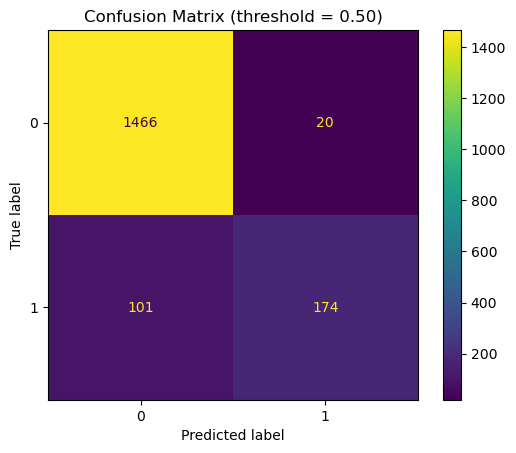

In [103]:
# visualize the confusion matrix with the default threshold=0.50
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (threshold = 0.50)")
plt.show()

The model correctly classified `1466 customers as retained (TN)` and `174 customers as churned (TP)`. The errors are distributed as follows: `20 false positives (the customer stayed, but the model predicted churn)` and `101 false negatives (the customer churned, but the model did not predict it)`. The main type of error in this case is `false negatives (FN)`. This means that in some cases the model fails to identify potential churn, which may lead to missed opportunities for customer retention. However, the number of such errors is relatively small, and the overall model performance remains high (ROC-AUC around 0.93), making it reliable enough for practical use.

### Precision and Recall Analysis of the Best Model

Next, we will evaluate the model’s performance using the `precision`, `recall`, and `F1-score` metrics. These metrics provide a more detailed understanding of how well the model identifies customers who are likely to churn. They are particularly useful in the presence of class imbalance, as they allow us to assess the trade-off between precision and recall.

In [104]:
# calculate additional model performance metrics
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

In [105]:
# print metric values
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

Precision: 0.90
Recall: 0.63
F1-score: 0.74


In [106]:
# print the full classification report with all evaluation metrics
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1486
           1       0.90      0.63      0.74       275

    accuracy                           0.93      1761
   macro avg       0.92      0.81      0.85      1761
weighted avg       0.93      0.93      0.93      1761



In [107]:
# compute precision and recall values for different probability thresholds
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba_test)

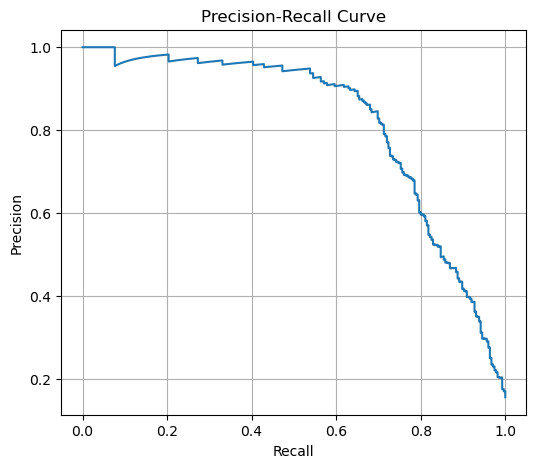

In [108]:
# plot Precision-Recall curve
plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

The model demonstrates strong overall performance on the test set: `accuracy is around 0.93`, while ROC-AUC and precision/recall values confirm the model’s good ability to distinguish customers at risk of churn. For the churn class (churn=1), the model achieves `precision of 0.90`, indicating a high accuracy in identifying customers classified as high-risk. However, the `recall is 0.63`, meaning that some customers who actually churn are not detected by the model. The Precision-Recall curve confirms this trade-off: as recall increases, precision gradually decreases, which is a typical behavior for classification tasks with moderate class imbalance.

### Optimal Threshold Selection

In this section, we will analyze the impact of the classification threshold on model performance. By default, a threshold of `0.5` is used, at which the model achieves a `recall of 0.63` for the churn class. Since the business objective is to identify as many at-risk customers as possible, the company is willing to sacrifice some precision in order to increase recall. Therefore, we will evaluate different threshold values and observe how the metrics `precision, recall, and F1-score` change.

In [109]:
# define a range of probability thresholds for analysis
thresholds = np.arange(0.1, 0.91, 0.05)
metrics = []

# iterate over different threshold values
for t in thresholds:
    # convert probabilities to class labels based on the current threshold
    y_pred_t = (y_proba_test >= t).astype(int)

    # compute evaluation metrics
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    # store the results
    metrics.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

In [110]:
# create a dataframe with the results and display it
threshold_df = pd.DataFrame(metrics)
display(threshold_df)

,threshold,precision,recall,f1
0,0.10,0.48,0.87,0.62
1,0.15,0.57,0.82,0.67
2,0.20,0.63,0.79,0.70
3,0.25,0.69,0.77,0.73
4,0.30,0.73,0.74,0.73
5,0.35,0.79,0.72,0.75
6,0.40,0.83,0.70,0.76
7,0.45,0.87,0.66,0.75
8,0.50,0.90,0.63,0.74
9,0.55,0.91,0.60,0.72


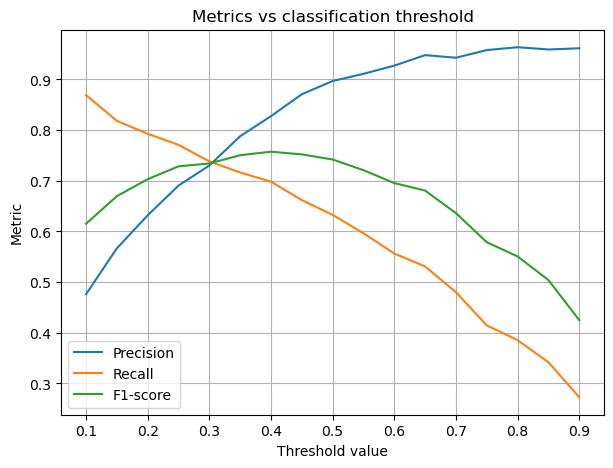

In [111]:
# show how precision, recall, and F1-score change for different thresholds
plt.figure(figsize=(7,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1-score")
plt.xlabel("Threshold value")
plt.ylabel("Metric")
plt.legend()
plt.grid()
plt.title("Metrics vs classification threshold")
plt.show()

The optimal balance between metrics is achieved at a `classification threshold of around 0.30`, where `recall increases to 0.74`, while `precision remains at a relatively high level of 0.73`. The `F1-score is 0.73`, indicating a good trade-off between precision and recall. Therefore, for the customer retention task, it is reasonable to set the classification `threshold to 0.30` in order to identify more customers at risk of churn while maintaining an acceptable level of prediction accuracy.

In [112]:
# set the optimal threshold
business_threshold = 0.30

In [113]:
# convert probabilities into classes using the selected threshold
y_pred_business = (y_proba_test >= business_threshold).astype(int)

In [114]:
# build the confusion matrix for the new threshold
cm_business = confusion_matrix(y_test, y_pred_business)

In [115]:
# calculate evaluation metrics for the selected classification threshold
precision_business = precision_score(y_test, y_pred_business)
recall_business = recall_score(y_test, y_pred_business)
f1_business = f1_score(y_test, y_pred_business)
accuracy_business = accuracy_score(y_test, y_pred_business)

In [116]:
# print evaluation metrics
print(f"Precision: {precision_business:.2f}")
print(f"Recall: {recall_business:.2f}")
print(f"F1-score: {f1_business:.2f}")
print(f"Accuracy: {accuracy_business:.2f}")

Precision: 0.73
Recall: 0.74
F1-score: 0.73
Accuracy: 0.92


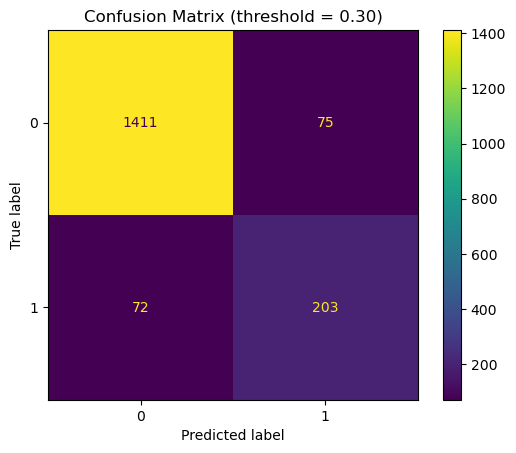

In [117]:
# visualize the confusion matrix for the new threshold
disp = ConfusionMatrixDisplay(confusion_matrix=cm_business)
disp.plot()
plt.title("Confusion Matrix (threshold = 0.30)")
plt.show()

After lowering the classification threshold from `0.50 to 0.30`, the balance of model errors changed. At the standard threshold of `0.50`, the model correctly identified `174 churn-prone customers (TP)` and missed `101 customers (FN)`. After reducing the threshold to `0.30`, the number of correctly detected churn cases increased to `203`, while the number of missed cases decreased to `72`. This indicates that the model became more effective at identifying customers at risk of churn. However, this improvement came at the cost of an increase in false positives: the number of FP rose from `20 to 75`. In other words, the model more frequently misclassified stable customers as being at risk.

Thus, lowering the threshold significantly improved `recall`, allowing the model to identify more potential churners, which aligns with the business objective of customer retention. At the same time, the increase in false positives is an expected trade-off for higher model sensitivity.

### Feature Importance Analysis

Next, we will perform a feature importance analysis. This will help us understand which customer characteristics have the greatest impact on churn prediction and which factors are most important for the model when making decisions.

In [118]:
# get feature importances from the trained model
feature_importances = best_model.get_feature_importance()

In [119]:
# get feature names
feature_names = X_train_cb.columns

In [120]:
# create a feature importance table
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

In [121]:
# display the top 15 most important features
display(importance_df.head(15))

,feature,importance
2,contract_duration_days,42.95
1,total_charges,10.27
0,monthly_charges,8.95
4,type,7.47
5,payment_method,5.92
3,num_services,4.02
14,multiple_lines,3.78
7,internet_service,3.28
17,partner,2.62
18,dependents,1.44


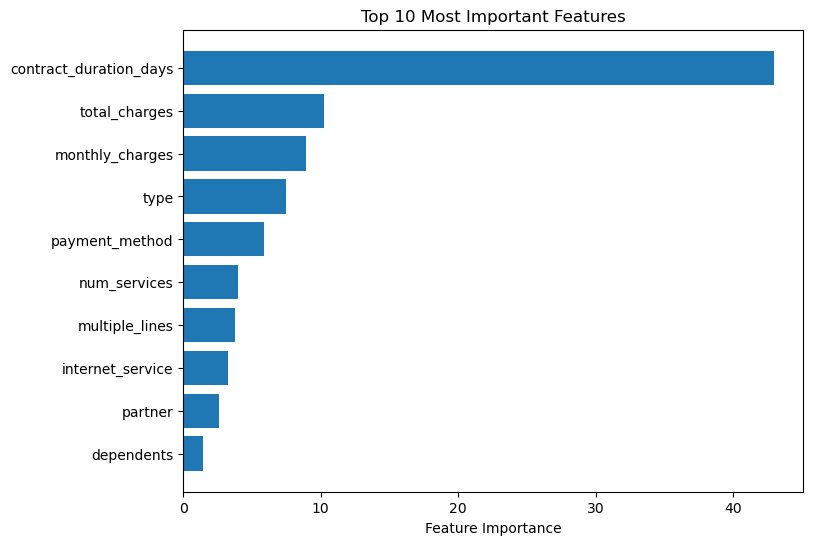

In [122]:
# select top-N features for visualization
top_n = 10
top_features = importance_df.head(top_n)

# plot feature importance
plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance")
plt.show()

Feature importance analysis shows that the most influential factor in predicting churn is the `customer tenure` (`contract_duration_days`), which significantly outweighs all other features. This indicates that the model heavily relies on the length of service when estimating the probability of customer churn. At the same time, EDA results showed that the distribution of contract duration partially overlaps for customers who churned and those who did not. Customers who left tend to have a slightly higher median tenure, while shorter durations are more common among those who stayed. This suggests that tenure alone does not determine churn, but becomes an important factor when combined with other features.

The next most important factors are financial characteristics (`total_charges`, `monthly_charges`), as well as contract type (`type`) and payment method (`payment_method`). Earlier EDA showed that monthly contracts are the most common, while customers with annual and two-year contracts have a higher churn rate, which may indicate the influence of contract conditions on the likelihood of leaving.

Other features (such as the `number of subscribed services, type of internet connection, whether the customer has multiple lines, and customer demographic characteristics`) have a noticeably smaller impact on the prediction.

Overall, the analysis confirms that the key drivers of churn are **contract conditions, customer tenure, and financial factors**.

### Analysis of Customer Tenure

Additionally, we will analyze the most important feature of the model - customer tenure (`contract_duration_days`). To do this, we will examine how the churn rate changes depending on the length of customer tenure in order to clearly assess the relationship between this feature and the target variable `churn`.

Since this feature is numerical, we will first divide it into intervals and calculate the average value of `churn` for each interval, for example, the proportion of customers who have left. This type of analysis allows us to observe how the churn rate varies depending on the duration of customer service and identify periods with higher or lower churn risk.

In [123]:
# create a copy of the dataframe with only the required columns
duration_df = data[['contract_duration_days', 'churn']].copy()

In [124]:
# split customer tenure into intervals
duration_df['duration_bin'] = pd.cut(
    duration_df['contract_duration_days'],
    bins=10
)

In [125]:
# calculate the number of customers and churn rate for each interval
duration_grouped = duration_df.groupby('duration_bin', observed=False).agg({
    'churn': ['mean', 'count']
})

In [126]:
# simplify column names and check the result
duration_grouped.columns = ['churn_rate', 'customer_count']
duration_grouped = duration_grouped.reset_index()
display(duration_grouped)

,duration_bin,churn_rate,customer_count
0,"(-2.314, 231.4]",0.05,1543
1,"(231.4, 462.8]",0.12,1016
2,"(462.8, 694.2]",0.23,714
3,"(694.2, 925.6]",0.25,750
4,"(925.6, 1157.0]",0.31,649
5,"(1157.0, 1388.4]",0.31,475
6,"(1388.4, 1619.8]",0.22,537
7,"(1619.8, 1851.2]",0.15,367
8,"(1851.2, 2082.6]",0.04,466
9,"(2082.6, 2314.0]",0.00,526


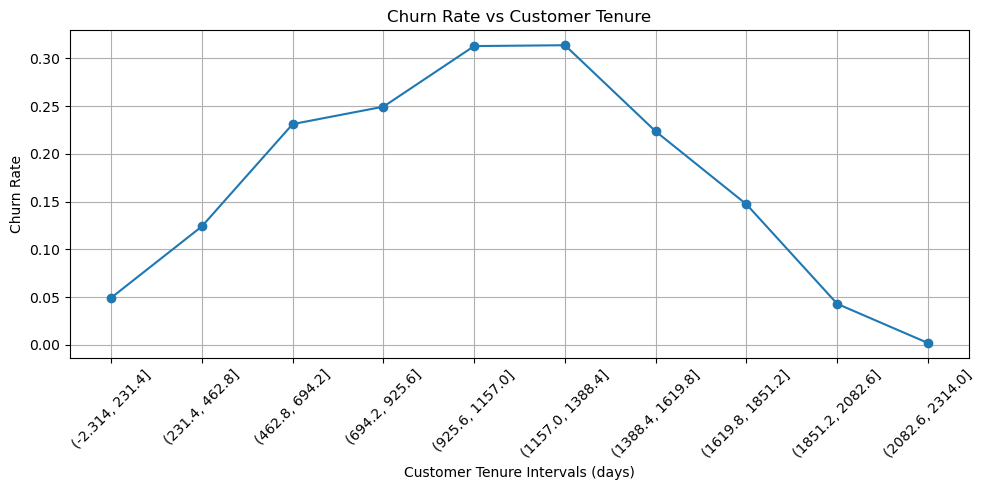

In [127]:
# plot the relationship between churn rate and customer tenure
plt.figure(figsize=(10, 5))
plt.plot(
    duration_grouped['duration_bin'].astype(str),
    duration_grouped['churn_rate'],
    marker='o'
)
# format the plot
plt.title('Churn Rate vs Customer Tenure')
plt.xlabel('Customer Tenure Intervals (days)')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

The churn rate varies with customer tenure. The highest churn rate is observed among customers with a service duration of approximately `900-1400 days`. For customers with a very short tenure (`up to 230 days`) and those with a long tenure (`more than 1800 days`), the churn rate is lower. This may indicate that customers who stay with the company for a long time become more loyal and are less likely to discontinue the service.

From a business perspective, this suggests that special attention should be paid to customers with a `medium tenure (approximately 2.5-4 years)`, as this period is associated with a higher churn risk. For these customers, it is advisable to proactively implement `retention programs, personalized offers, or bonuses.`

**Summary**

<div style="border:solid lightblue 3px; padding: 20px">

- The best model, `CatBoost with tuned hyperparameters`, selected during the training phase, was evaluated on the test dataset.
- The model demonstrated high performance: `ROC-AUC around 0.93` and `accuracy around 0.93`, indicating a strong ability to distinguish customers at risk of churn.
- The confusion matrix analysis showed that most customers were classified correctly. However, the main type of error is `false negatives`, where churned customers were not identified by the model.
- Additional evaluation using `precision, recall, and F1-score` showed high precision but moderate recall for the churn class.
- A classification threshold analysis revealed that lowering the threshold from `0.50 to 0.30` increases recall and allows the model to detect more customers at risk of churn, which better aligns with the business objective of customer retention.
- Feature importance analysis showed that the most influential factors are `customer tenure, spending level, and contract conditions`.
- A deeper analysis of the most important feature, `customer tenure`, revealed that the highest churn risk occurs among customers with a medium tenure (approximately `2.5-4 years`).

**Thus, the CatBoost model with tuned hyperparameters can be used for early detection of potential churn and launching retention strategies, helping to reduce customer loss and improve long-term customer loyalty**.

## Conclusion

<div style="border:solid lightblue 3px; padding: 20px">

**Data Processing Comments:**

- The data was successfully loaded from the `ds-plus-final.db` file. Four tables were used to solve the task: `contract, personal, internet, and phone`, containing information about contracts, customers, and subscribed services.
- Before joining the tables, the data structure was validated, column names were standardized to `snake_case`, data types were corrected (dates and numerical features), and distributions of categorical and numerical variables were analyzed.
- The tables were joined using `customer_id`, resulting in a unified dataset of `7043 × 20`. Missing values in internet and phone-related features are explained by the absence of corresponding services for some customers and are not considered data errors.

**Model Comparison and Best Model Description:**

- Several models were tested for the binary classification task: `DummyClassifier (baseline), RandomForest, CatBoost, and a neural network (MLP)`. The comparison was performed using the `ROC-AUC` metric and `StratifiedKFold` cross-validation.
- The baseline `DummyClassifier` achieved a ROC-AUC of around `0.50`, which corresponds to random guessing and confirms that more complex models extract meaningful patterns from the data.
- Among the machine learning models, `CatBoost` showed the best performance. After hyperparameter tuning using `RandomizedSearchCV`, its performance reached `ROC-AUC around 0.91` on cross-validation and `ROC-AUC around 0.93` on the test set.
- Feature importance analysis showed that the most influential factors for churn prediction are `customer tenure, spending level (monthly_charges, total_charges), and contract conditions`, while demographic features have significantly less impact.

**Practical Application:**

- The developed model can be used for `early identification of customers at high risk of churn`, allowing the company to take proactive retention actions.
- Threshold analysis showed that lowering the classification threshold to `0.30` increases recall, which is especially important for churn detection tasks.
- Feature analysis helps the company better understand key drivers of churn, such as tenure and financial factors.

**Limitations:**

- The model is trained on historical data and may perform worse if customer behavior or pricing policies change.
- Some features are partially correlated (`total_charges and contract_duration_days`), which reflects the business logic of accumulated costs.
- The model does not account for external factors, such as competitor actions, price changes, or marketing campaigns.

**Possible Improvements:**

- Adding new features reflecting customer behavior over time (`usage frequency, plan changes, activity dynamics`).
- Applying additional class balancing techniques or threshold optimization to improve recall.
- Building more advanced models or ensembles and performing further hyperparameter tuning.

**Business Recommendations:**

- The model can be used for regular customer scoring (for example, on a monthly basis) to identify high-risk customers in advance and enable timely retention actions before churn occurs.
- Customers with medium tenure (`2.5-4 years`) represent the highest churn risk group. For this segment, proactive measures such as `loyalty programs, contract extensions on favorable terms, or personalized offers` may be particularly effective.
- Since important churn factors include `monthly payments and total charges`, the company should consider:
  - offering `more flexible pricing plans`,
  - providing `temporary discounts or bonuses`,
  - introducing `bundled services` to reduce overall cost for customers.
- The analysis also showed the impact of `contract type and payment method`, so customers can be encouraged to switch to `long-term contracts` (for example, through discounts or additional services).
- For customers actively using multiple services, the company can implement `personalized service bundles and additional digital products` to increase engagement and reduce churn risk.
- Integrating the model into a CRM system will allow automatic `generation of high-risk customer lists` for marketing or support teams, enabling timely personalized interventions to prevent churn.

[Back to Table of Contents](#Table-of-Contents)